### Basic

In [152]:
!pip install lightgbm xgboost optuna rich seaborn matplotlib sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [ ]:
!python --version
!pip --version

In [ ]:
import numpy as np
import pandas as pd
import tabulate as tb

from rich import box
from rich.rule import Rule
from rich.panel import Panel 
from rich.pretty import Pretty
from rich.console import Console, Group

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# basic config for the project 

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

console = Console()
#Function to help improve the data visulization 
def printf(*sections, title="", subtitle="", border_style="green"):
    renderables = []
    
    for i, section in enumerate(sections):
        if i > 0:
            renderables.append(Rule(style="dim"))

        if isinstance(section, str):
            renderables.append(section)
        else:
            renderables.append(Pretty(section))

    if not renderables:
        renderables.append("")

    console.print(
        Panel(
            Group(*renderables),
            title=f"[bold cyan]>>> {title} <<<[/bold cyan]",
            subtitle=f"[yellow]{subtitle}[/yellow]",
            box=box.HEAVY,
            border_style=border_style,
        )
    )

In [131]:
printf("Hello ML Arena 🚀",
    title="State Level Challenge",
    subtitle="IEEE X GEHU",
)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> State Level Challenge <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Hello ML Arena 🚀                                                                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ IEEE X GEHU ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

### Traning Data

In [ ]:
train_path = "Dataset/Train.csv"
train_df = pd.read_csv(train_path)

#Display data values
printf(train_df.head(5),title = "Data preview")
printf(train_df.describe(), title="Description")
printf(train_df.isnull().sum(),title = "Null Values")


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Data preview <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         F01       F02       F03       F04       F05       F06       F07  \                                      ┃
┃ 0  0.185570  0.004568  0.005362  0.003335  0.005415  0.004895  0.012764                                         ┃
┃ 1  0.369536  0.003983  0.003386  0.004902  0.007570  0.012136  0.118050                                         ┃
┃ 2  0.602510  0.008442  0.012961  0.012870  0.046885  0.115401  0.065688                                         ┃
┃ 3  0.347957  0.064721  0.013611  0.011541  0.006492  0.008690  0.013192                                         ┃
┃ 4  0.233653  0.012217  0.010088  0.022095  0.026040  0.015062  0.016063                                         ┃
┃                                                                                                                 ┃
┃         F08       F09       F10  ...       F39        F40       F41       F42  \                                ┃
┃ 0  0.120138  0.140450  3.361753  ...  0.041526  -0.230857  0.003310  0.042250                                   ┃
┃ 1  0.323925  0.132093  2.766117  ... -0.141285  -6.222857  0.834177  0.227968                                   ┃
┃ 2  0.306677  0.498805  4.521201  ...  0.011334  10.335251 -0.276614 -0.198900                                   ┃
┃ 3  0.164553  0.298665  3.170847  ...  0.190479   2.864912 -1.921939  0.891690                                   ┃
┃ 4  0.084648  0.213367  8.150943  ...  0.203164   0.001812 -0.092731  0.005280                                   ┃
┃                                                                                                                 ┃
┃         F43       F44       F45       F46       F47  Class                                                      ┃
┃ 0  0.005975  0.002104  0.013878  0.001518  0.011347      0                                                      ┃
┃ 1  0.018463 -0.020487  0.001246  0.007489  0.008724      1                                                      ┃
┃ 2 -0.012756  0.014286 -0.001866  0.002687  0.013452      1                                                      ┃
┃ 3  1.108098  0.635431  0.081368 -0.000225  0.009166      0                                                      ┃
┃ 4 -0.213985  0.032195  0.002081  0.028930 -0.025912      1                                                      ┃
┃                                                                                                                 ┃
┃ [5 rows x 48 columns]                                                                                           ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Description <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                 F01           F02           F03           F04           F05  \                                  ┃
┃ count  43776.000000  43776.000000  43776.000000  43776.000000  43776.000000                                     ┃
┃ mean       0.567525      0.014285      0.015551      0.026779      0.087637                                     ┃
┃ std        0.738884      0.019607      0.022504      0.050725      0.188394                                     ┃
┃ min        0.100025      0.003001      0.000752      0.000682      0.000835                                     ┃
┃ 25%        0.198843      0.004778      0.005437      0.006290      0.012050                                     ┃
┃ 50%        0.288778      0.007988      0.008905      0.012619      0.023681                                     ┃
┃ 75%        0.528760      0.014382      0.016610      0.027599      0.063469                                     ┃
┃ max       12.779628      0.199925      0.506419      0.851009      5.017180                                     ┃
┃                                                                                                                 ┃
┃                 F06           F07           F08           F09           F10  \                                  ┃
┃ count  43776.000000  43776.000000  43776.000000  43776.000000  43776.000000                                     ┃
┃ mean       0.155142      0.150656      0.255644      0.361146      3.762811                                     ┃
┃ std        0.377655      0.339948      0.354816      0.440134      1.271343                                     ┃
┃ min        0.000854      0.000702      0.001399      0.001164      0.038349                                     ┃
┃ 25%        0.014112      0.015084      0.072098      0.128780      3.192588                                     ┃
┃ 50%        0.032396      0.029157      0.119095      0.214665      3.604579                                     ┃
┃ 75%        0.115950      0.116992      0.265227      0.381230      4.035824                                     ┃
┃ max        7.249545      6.556998      5.960009      5.085546     50.624777                                     ┃
┃                                                                                                                 ┃
┃        ...           F39           F40           F41           F42  \                                           ┃
┃ count  ...  43776.000000  43776.000000  43776.000000  43776.000000                                              ┃
┃ mean   ...      0.023477     -0.039795      0.005846     -0.000089                                              ┃
┃ std    ...      0.707224      8.462749      1.631328      1.103486                                              ┃
┃ min    ...    -22.647806    -28.026880     -9.109769     -9.275399                                              ┃
┃ 25%    ...     -0.036589     -0.254039     -0.117789     -0.015759                                              ┃
┃ 50%    ...     -0.000210     -0.000757     -0.002891     -0.000111                                              ┃
┃ 75%    ...      0.043276      0.171122      0.107351      0.013399                                              ┃
┃ max    ...     89.378571     28.471415     10.907778      9.374269                                              ┃
┃                                                                                                                 ┃
┃                 F43           F44           F45           F46           F47  \                                  ┃
┃ count  43776.000000  43776.000000  43776.000000  43776.000000  43776.000000                                     ┃
┃ mean       0.003215      0.001007      0.004599      0.003981     -0.006780                                     ┃
┃ std        0.354742      0.171935      0.201611      0

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Null Values <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ F01      0                                                                                                      ┃
┃ F02      0                                                                                                      ┃
┃ F03      0                                                                                                      ┃
┃ F04      0                                                                                                      ┃
┃ F05      0                                                                                                      ┃
┃ F06      0                                                                                                      ┃
┃ F07      0                                                                                                      ┃
┃ F08      0                                                                                                      ┃
┃ F09      0                                                                                                      ┃
┃ F10      0                                                                                                      ┃
┃ F11      0                                                                                                      ┃
┃ F12      0                                                                                                      ┃
┃ F13      0                                                                                                      ┃
┃ F14      0                                                                                                      ┃
┃ F15      0                                                                                                      ┃
┃ F16      0                                                                                                      ┃
┃ F17      0                                                                                                      ┃
┃ F18      0                                                                                                      ┃
┃ F19      0                                                                                                      ┃
┃ F20      0                                                                                                      ┃
┃ F21      0                                                                                                      ┃
┃ F22      0                                                                                                      ┃
┃ F23      0                                                                                                      ┃
┃ F24      0                                                                                                      ┃
┃ F25      0                                                                                                      ┃
┃ F26      0                                                                                                      ┃
┃ F27      0                                                                                                      ┃
┃ F28      0                                                                                                      ┃
┃ F29      0                                                                                                      ┃
┃ F30      0                                                                                                      ┃
┃ F31      0                                                                                                      ┃
┃ F32      0                                                                                                      ┃
┃ F33      0                                                                                                      ┃
┃ F34      0                                            

In [ ]:
# Display Basic Info 
temp =""
temp+= f"Shape : {train_df.shape}\n"
temp+= f"Duplicate rows: {train_df.duplicated().sum()}\n"
missing = train_df.isnull().sum()
if (missing.sum() > 0):
    temp+= str(missing[missing > 0]) +"\n"
else :
    temp +="No missing values ✅\n"
temp+= f"Total missing cells: {missing.sum()}"
printf(temp, title=">>> Basic Info <<<")


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> >>> Basic Info <<< <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Shape : (43776, 48)                                                                                             ┃
┃ Duplicate rows: 738                                                                                             ┃
┃ No missing values ✅                                                                                            ┃
┃ Total missing cells: 0                                                                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [130]:
# Class Distribution 

printf(train_df['Class'].value_counts().to_string(),f"\nClass ratio (0:1) = 1:{train_df['Class'].value_counts()[1] / train_df['Class'].value_counts()[0]:.2f}",title="Class Distribution")


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Class Distribution <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Class                                                                                                           ┃
┃ 0    26465                                                                                                      ┃
┃ 1    17311                                                                                                      ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃                                                                                                                 ┃
┃ Class ratio (0:1) = 1:0.65                                                                                      ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

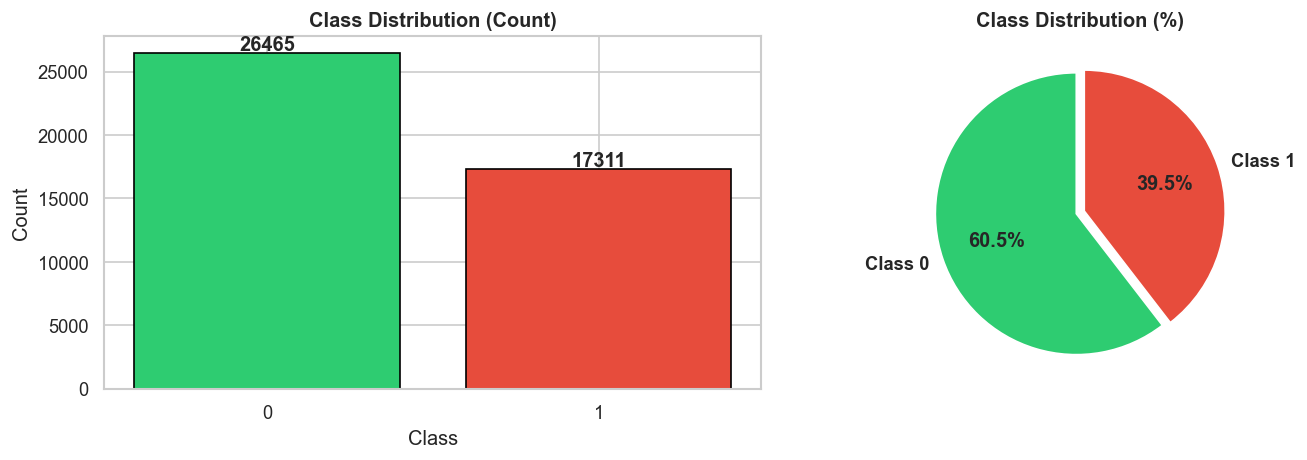

In [ ]:
#Class Distribution (Bar + Pie)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts = train_df['Class'].value_counts()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title("Class Distribution (Count)", fontweight='bold')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Class 0', 'Class 1'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.03, 0.03),
            textprops={'fontweight': 'bold'})
axes[1].set_title("Class Distribution (%)", fontweight='bold')

plt.tight_layout()
plt.show()

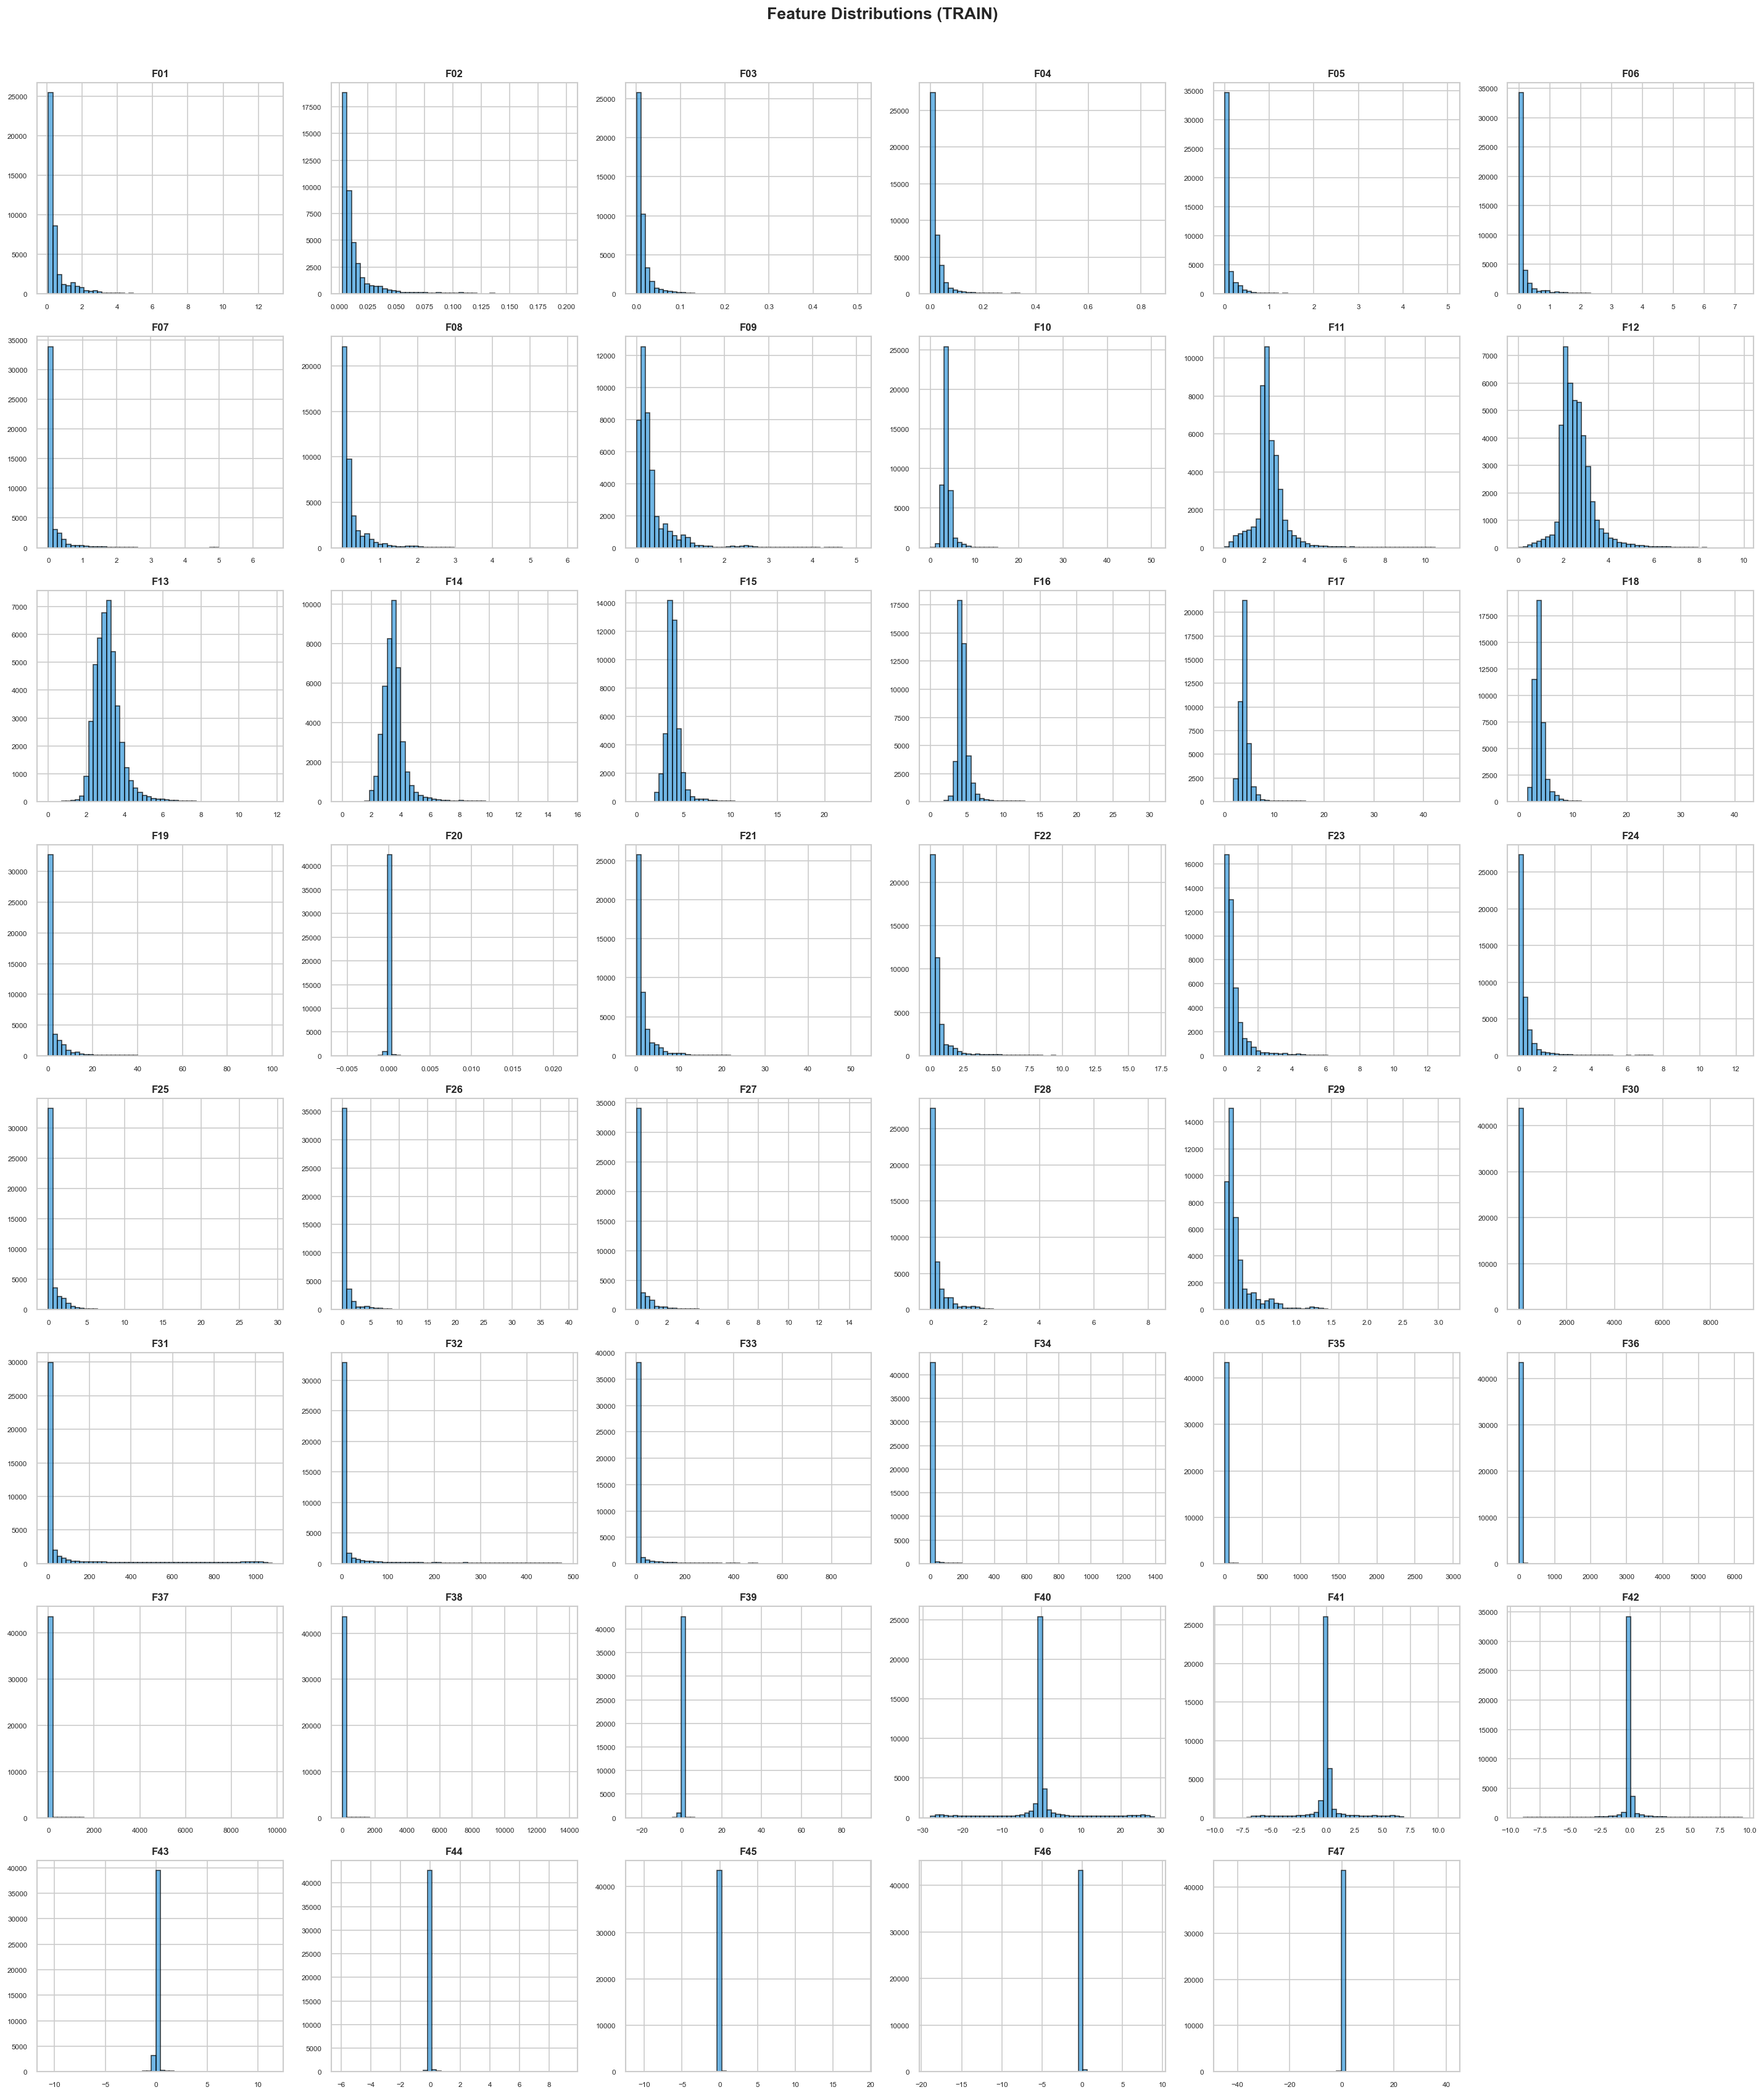

In [ ]:
#Feature Distributions (Histograms for all 47 features)
feature_cols = [c for c in train_df.columns if c not in ['ID', 'Class']]

fig, axes = plt.subplots(8, 6, figsize=(24, 28))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    train_df[col].hist(bins=50, ax=axes[i], color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=7)

# hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions (TRAIN)", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

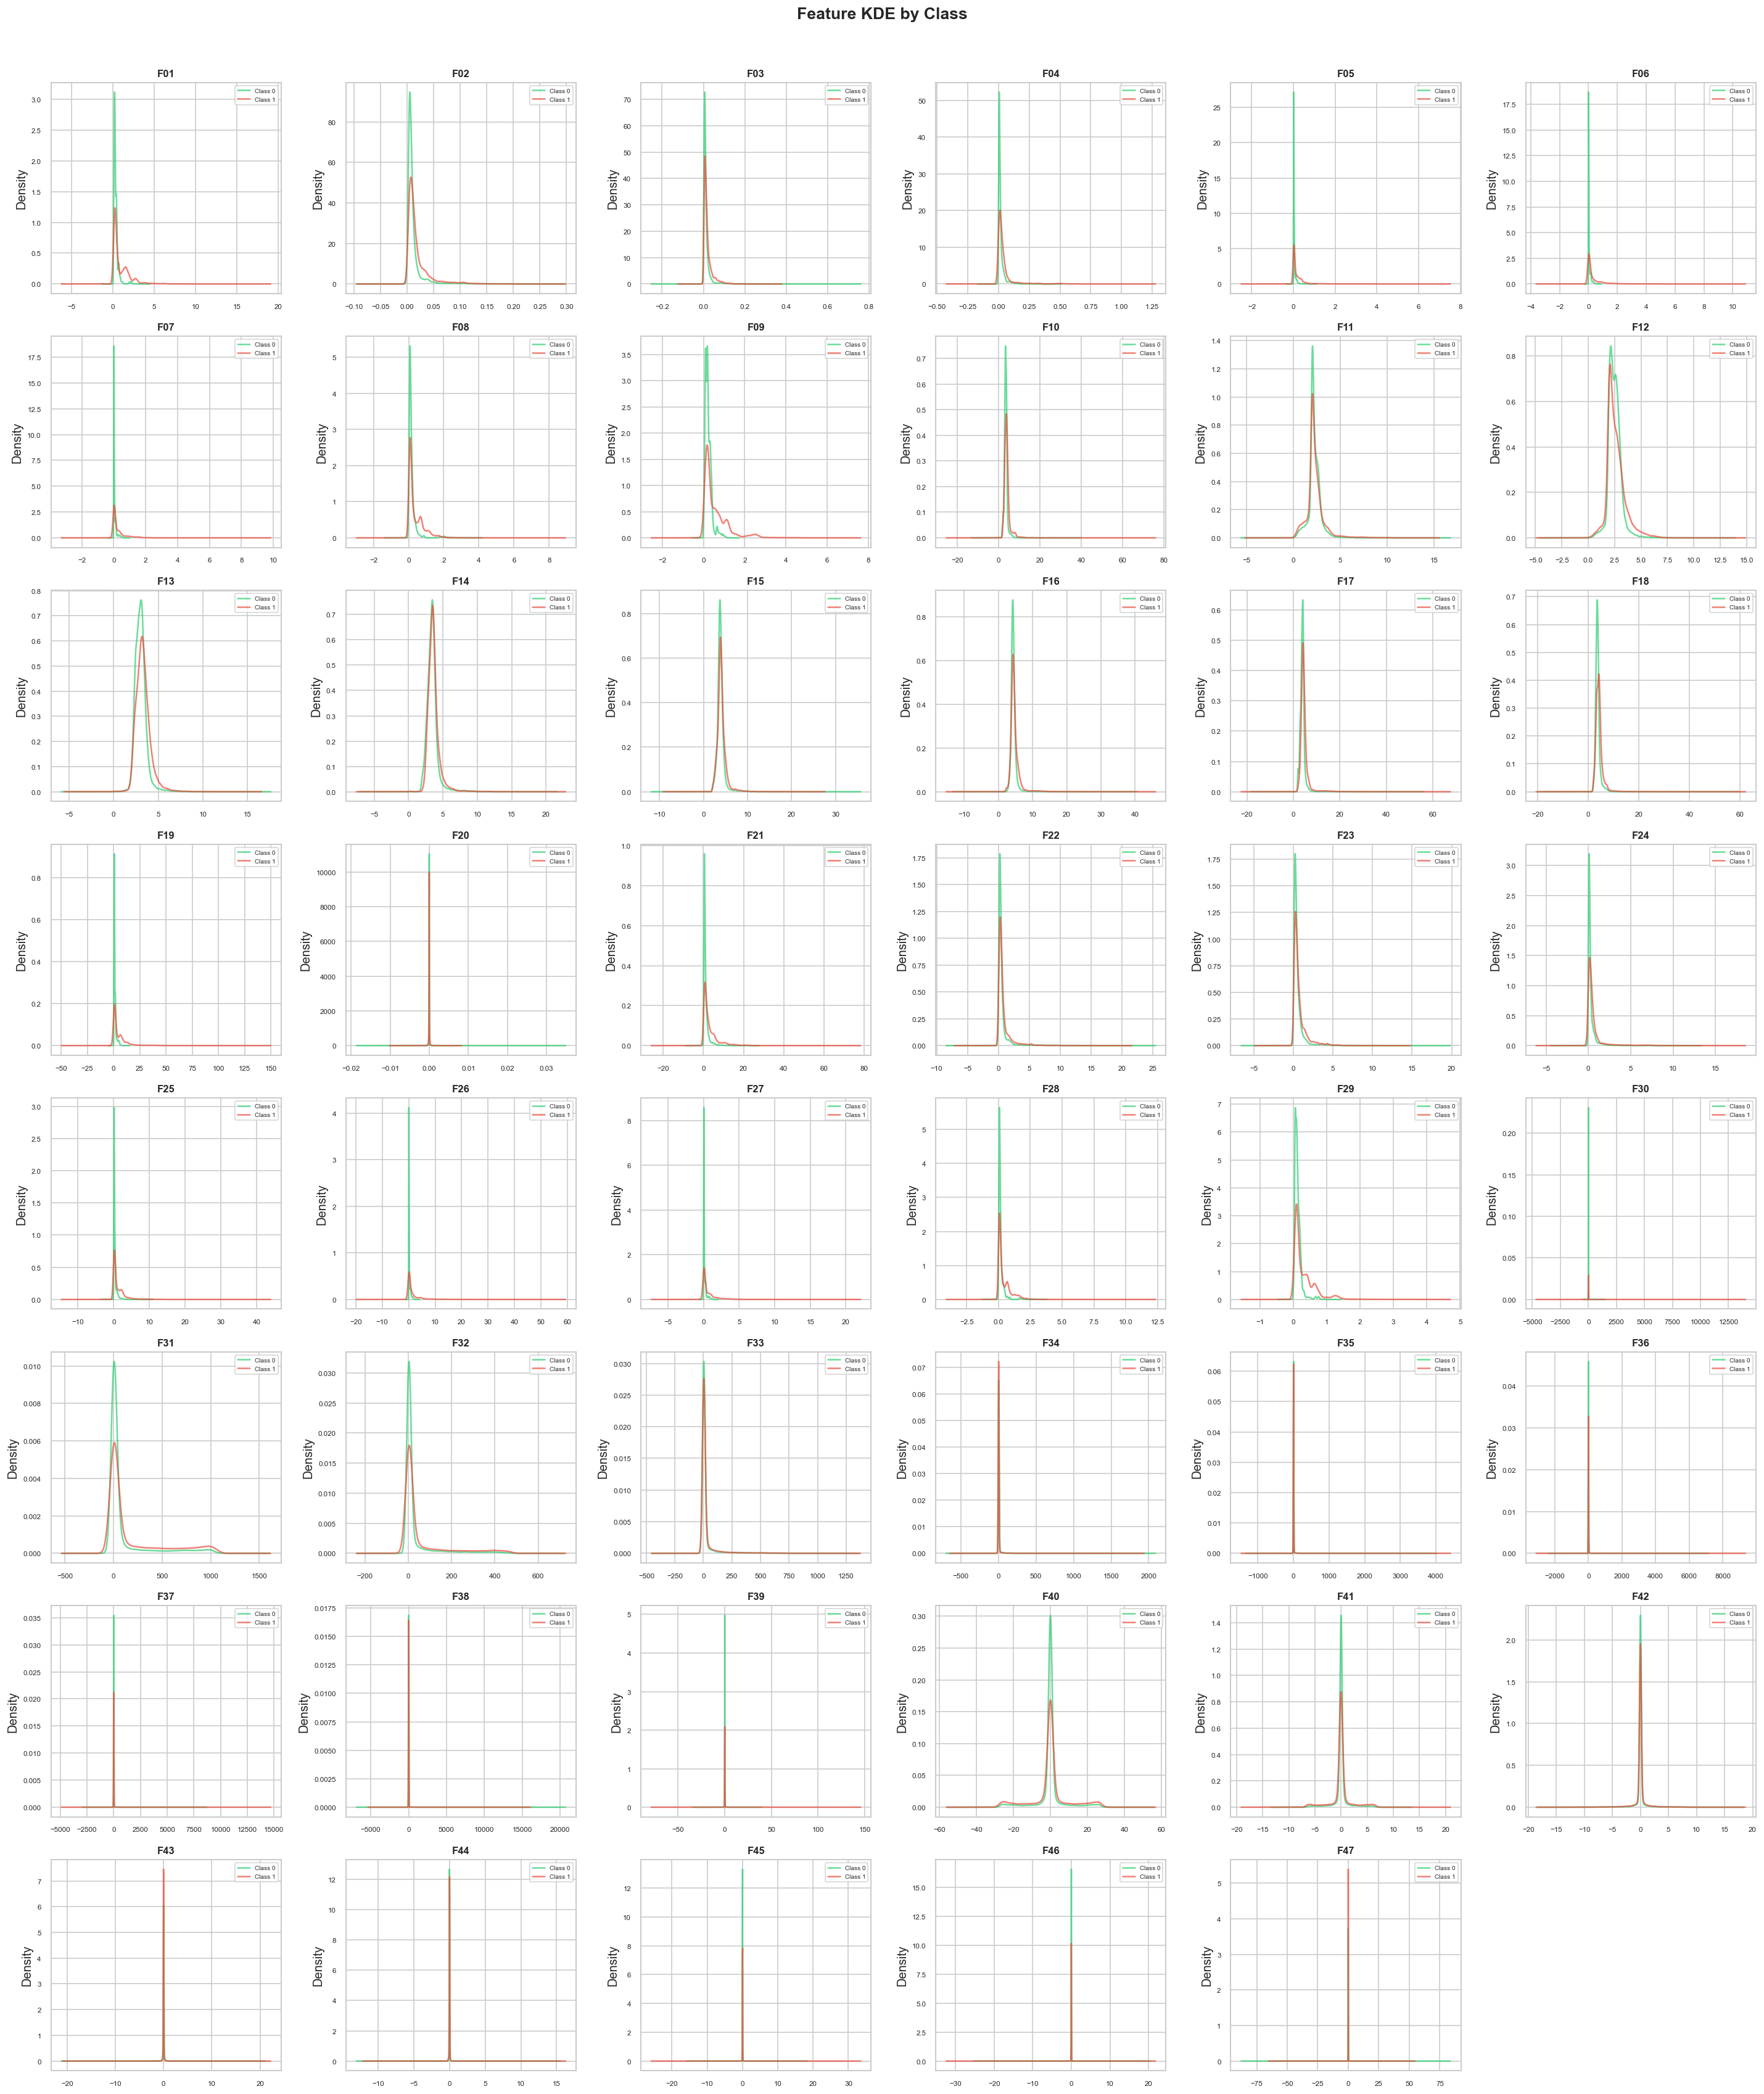

In [142]:
#Distributions split by Class (KDE overlay)
fig, axes = plt.subplots(8, 6, figsize=(24, 28))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for cls, color, label in [(0, '#2ecc71', 'Class 0'), (1, '#e74c3c', 'Class 1')]:
        subset = train_df[train_df['Class'] == cls][col]
        subset.plot.kde(ax=axes[i], color=color, label=label, alpha=0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=6)
    axes[i].tick_params(labelsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature KDE by Class", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

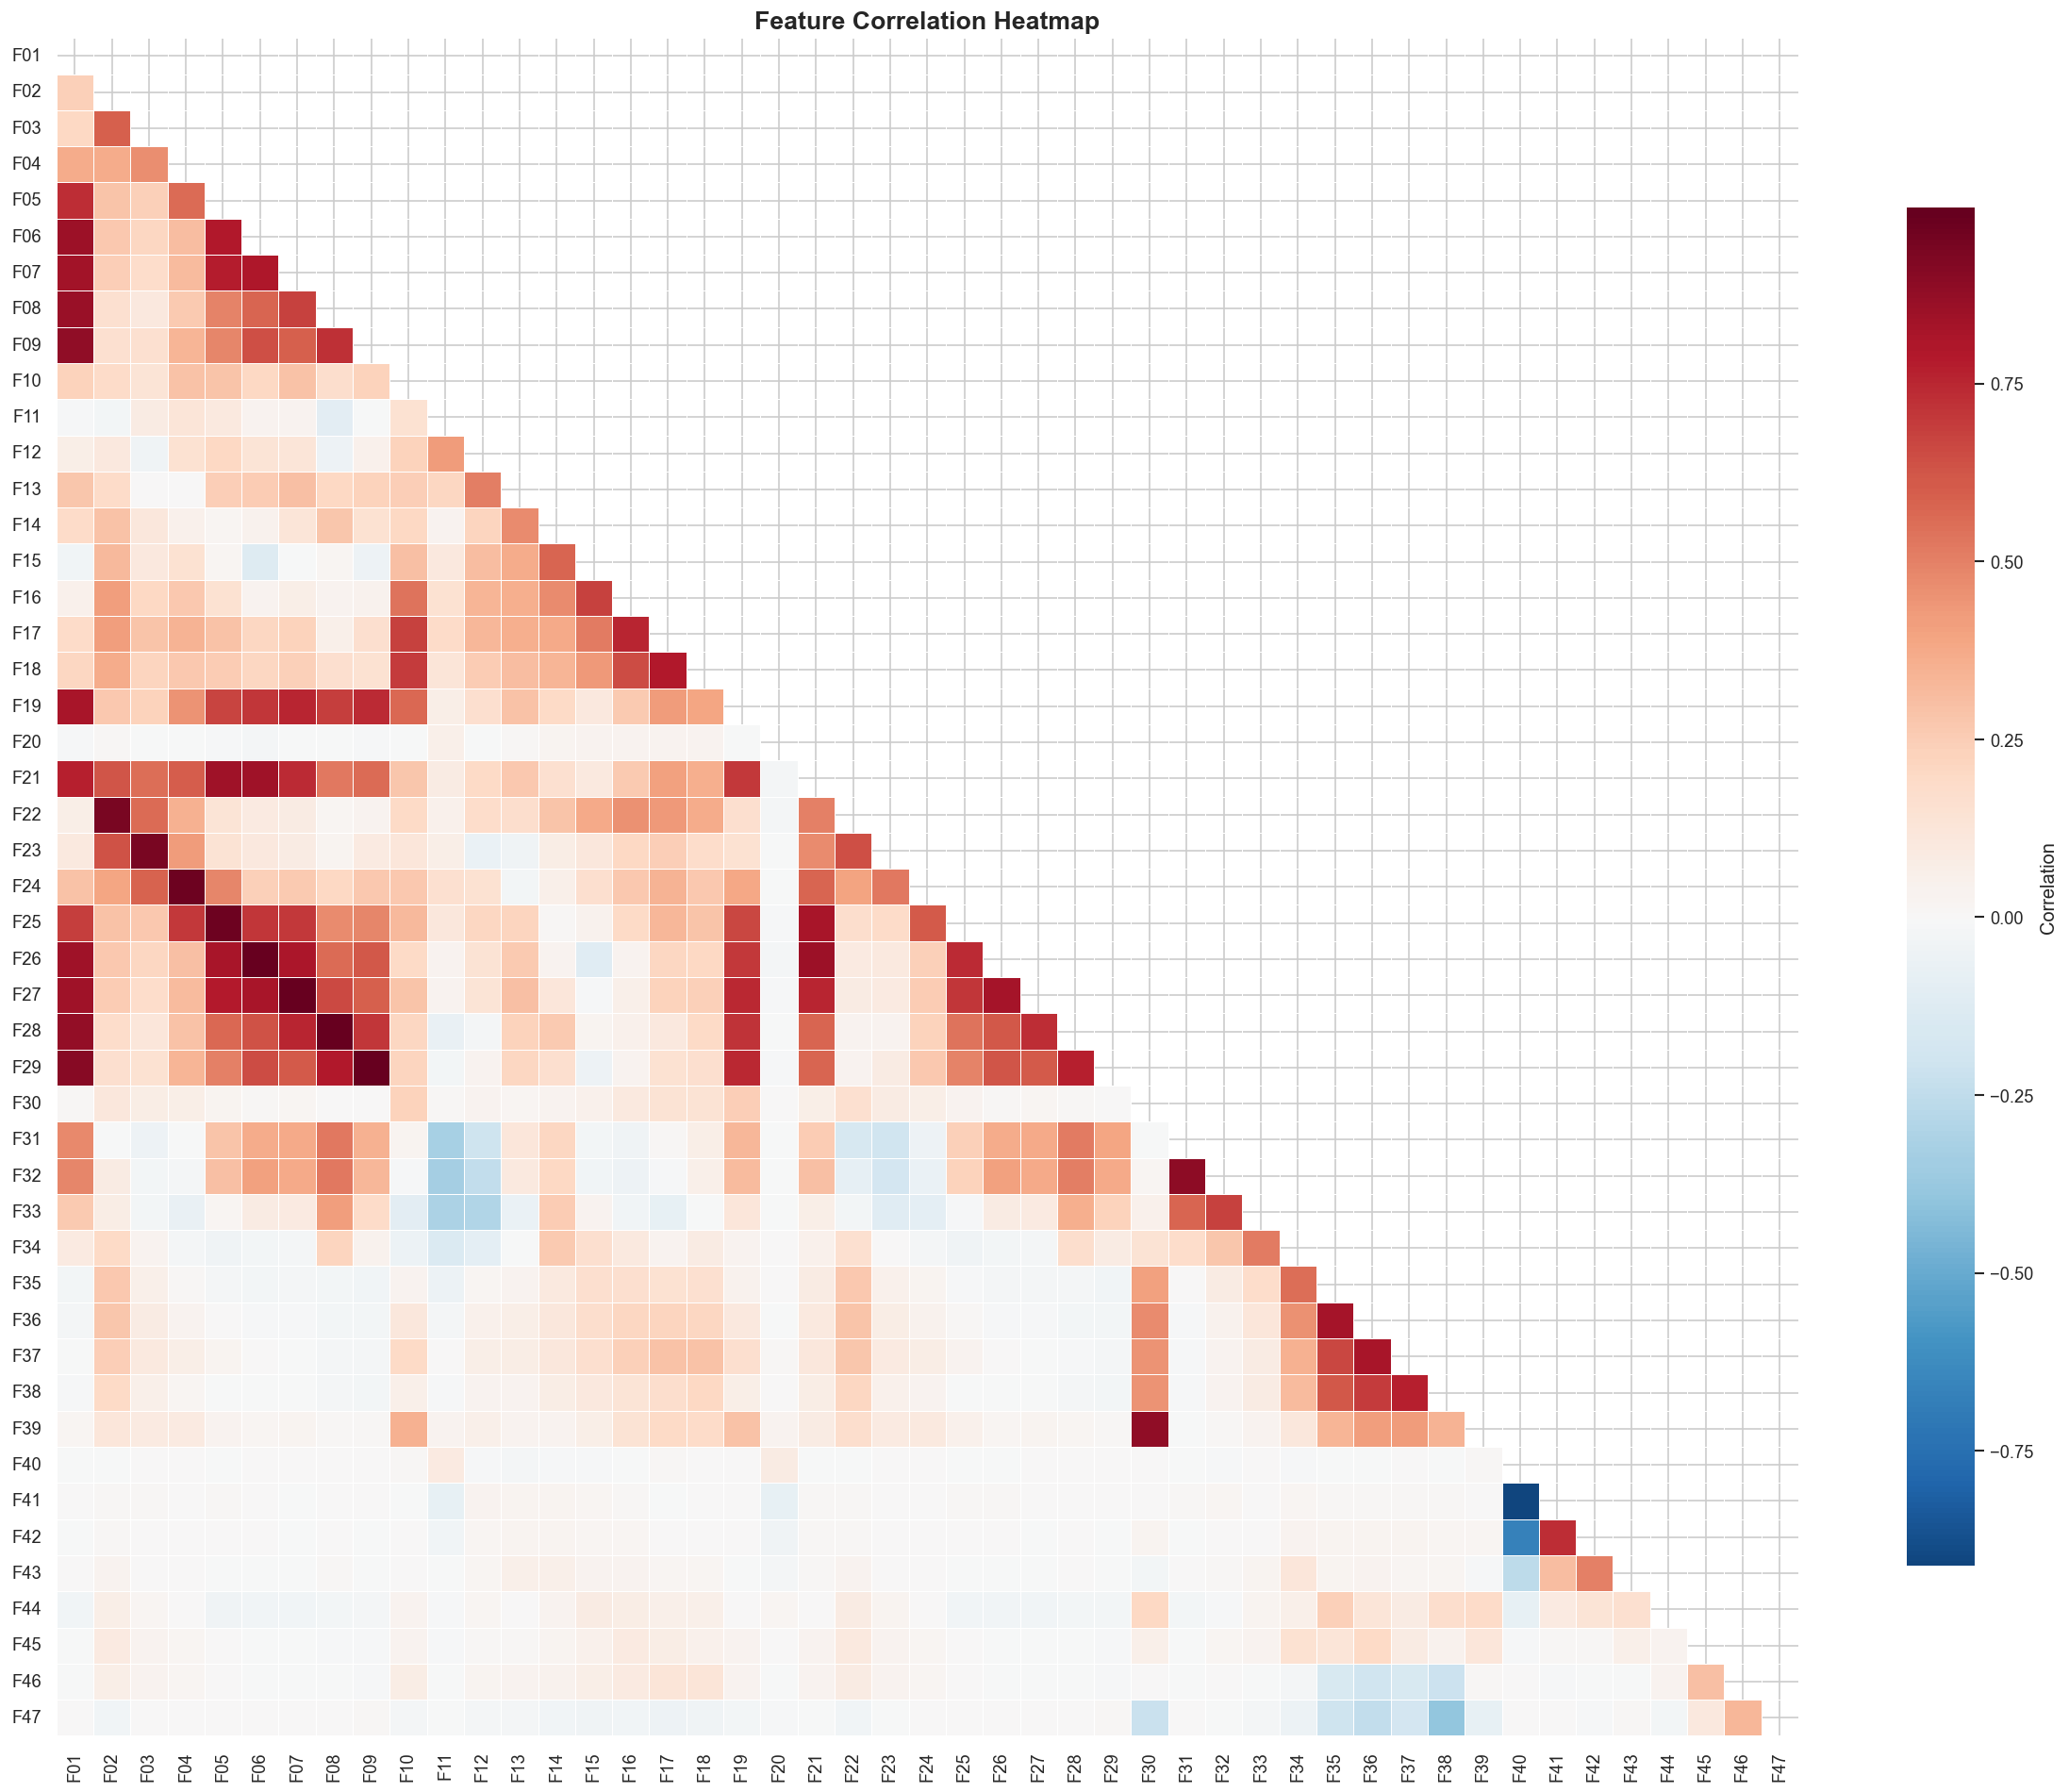

In [143]:
#Correlation Heatmap
fig, ax = plt.subplots(figsize=(20, 16))
corr = train_df[feature_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.3,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [147]:
#Top correlated feature pairs
# Find pairs with |correlation| > 0.8
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            corr_pairs.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

corr_pairs_df = pd.DataFrame(corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
corr_pairs_df = corr_pairs_df.sort_values('Correlation', key=abs, ascending=False).reset_index(drop=True)

printf(f"Highly correlated pairs (|r| > 0.8): {len(corr_pairs_df)}",corr_pairs_df.to_string(),title = "Correlation Pairs")


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Correlation Pairs <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Highly correlated pairs (|r| > 0.8): 31                                                                         ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃    Feature 1 Feature 2  Correlation                                                                             ┃
┃ 0        F07       F27        0.997                                                                             ┃
┃ 1        F06       F26        0.996                                                                             ┃
┃ 2        F09       F29        0.990                                                                             ┃
┃ 3        F08       F28        0.984                                                                             ┃
┃ 4        F04       F24        0.975                                                                             ┃
┃ 5        F05       F25        0.974                                                                             ┃
┃ 6        F03       F23        0.942                                                                             ┃
┃ 7        F02       F22        0.940                                                                             ┃
┃ 8        F40       F41       -0.912                                                                             ┃
┃ 9        F01       F29        0.904                                                                             ┃
┃ 10       F31       F32        0.886                                                                             ┃
┃ 11       F01       F09        0.881                                                                             ┃
┃ 12       F30       F39        0.881                                                                             ┃
┃ 13       F01       F28        0.874                                                                             ┃
┃ 14       F01       F08        0.860                                                                             ┃
┃ 15       F01       F06        0.855                                                                             ┃
┃ 16       F21       F26        0.852                                                                             ┃
┃ 17       F01       F26        0.846                                                                             ┃
┃ 18       F05       F21        0.846                                                                             ┃
┃ 19       F06       F21        0.843                                                                             ┃
┃ 20       F01       F27        0.841                                                                             ┃
┃ 21       F01       F07        0.839                                                                             ┃
┃ 22       F26       F27        0.829                                                                             ┃
┃ 23       F35       F36        0.828                                                                             ┃
┃ 24       F05       F26        0.825                                                                             ┃
┃ 25       F21       F25        0.825                                                                             ┃
┃ 26       F01       F19        0.824                                                                             ┃
┃ 27       F36       F37        0.824                                                                             ┃
┃ 28       F06       F27        0.821                                                                             ┃
┃ 29       F07       F26        0.813                                                                             ┃
┃ 30       F06       F07        0.805                   

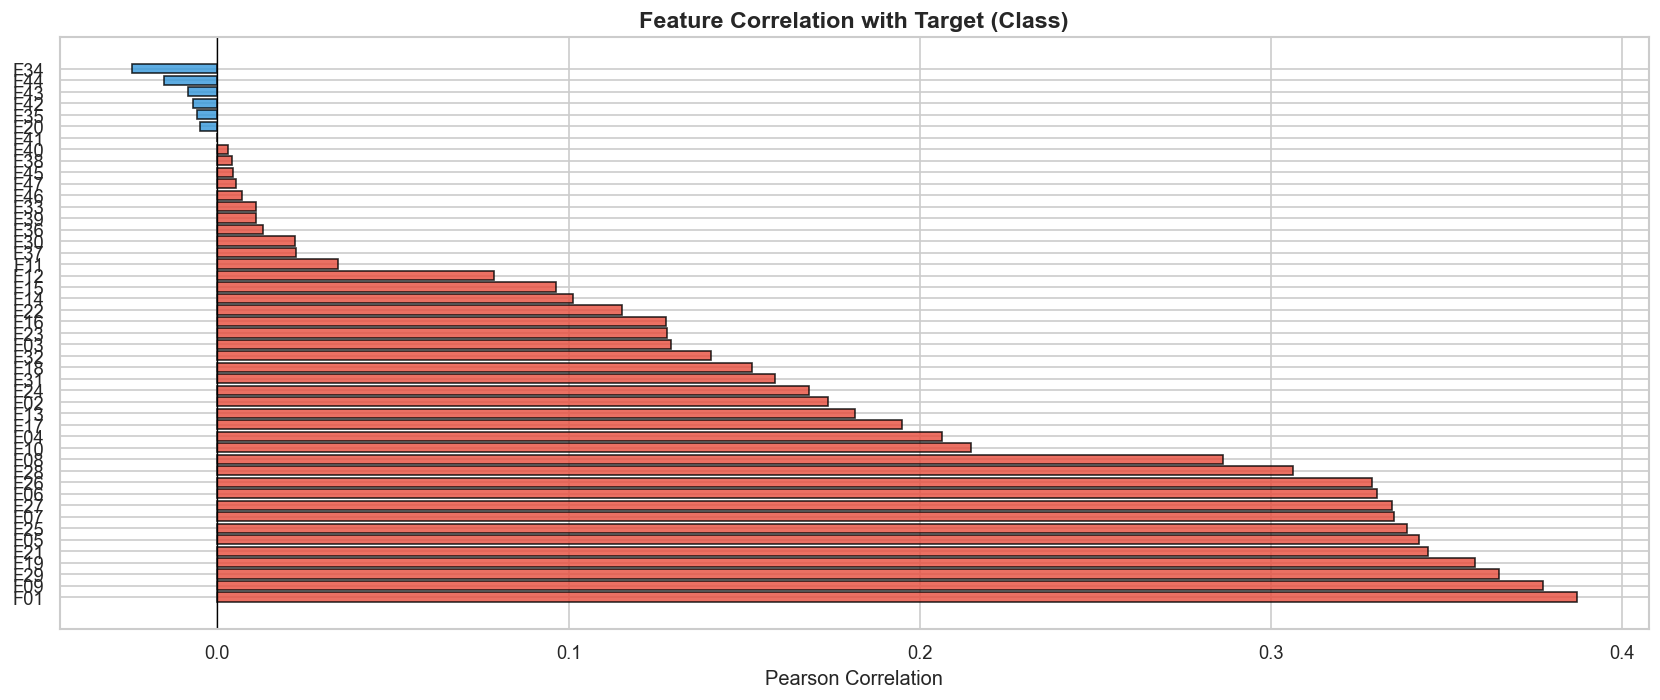

In [148]:
#Correlation of each feature with target
target_corr = train_df[feature_cols + ['Class']].corr()['Class'].drop('Class').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_title("Feature Correlation with Target (Class)", fontsize=14, fontweight='bold')
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\2917671931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Class', y=col, ax=axes[i],
C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\2917671931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Class', y=col, ax=axes[i],
C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\2917671931.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Class', y=col, ax=axes[i],
C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\2917671931.py:8: FutureWarn

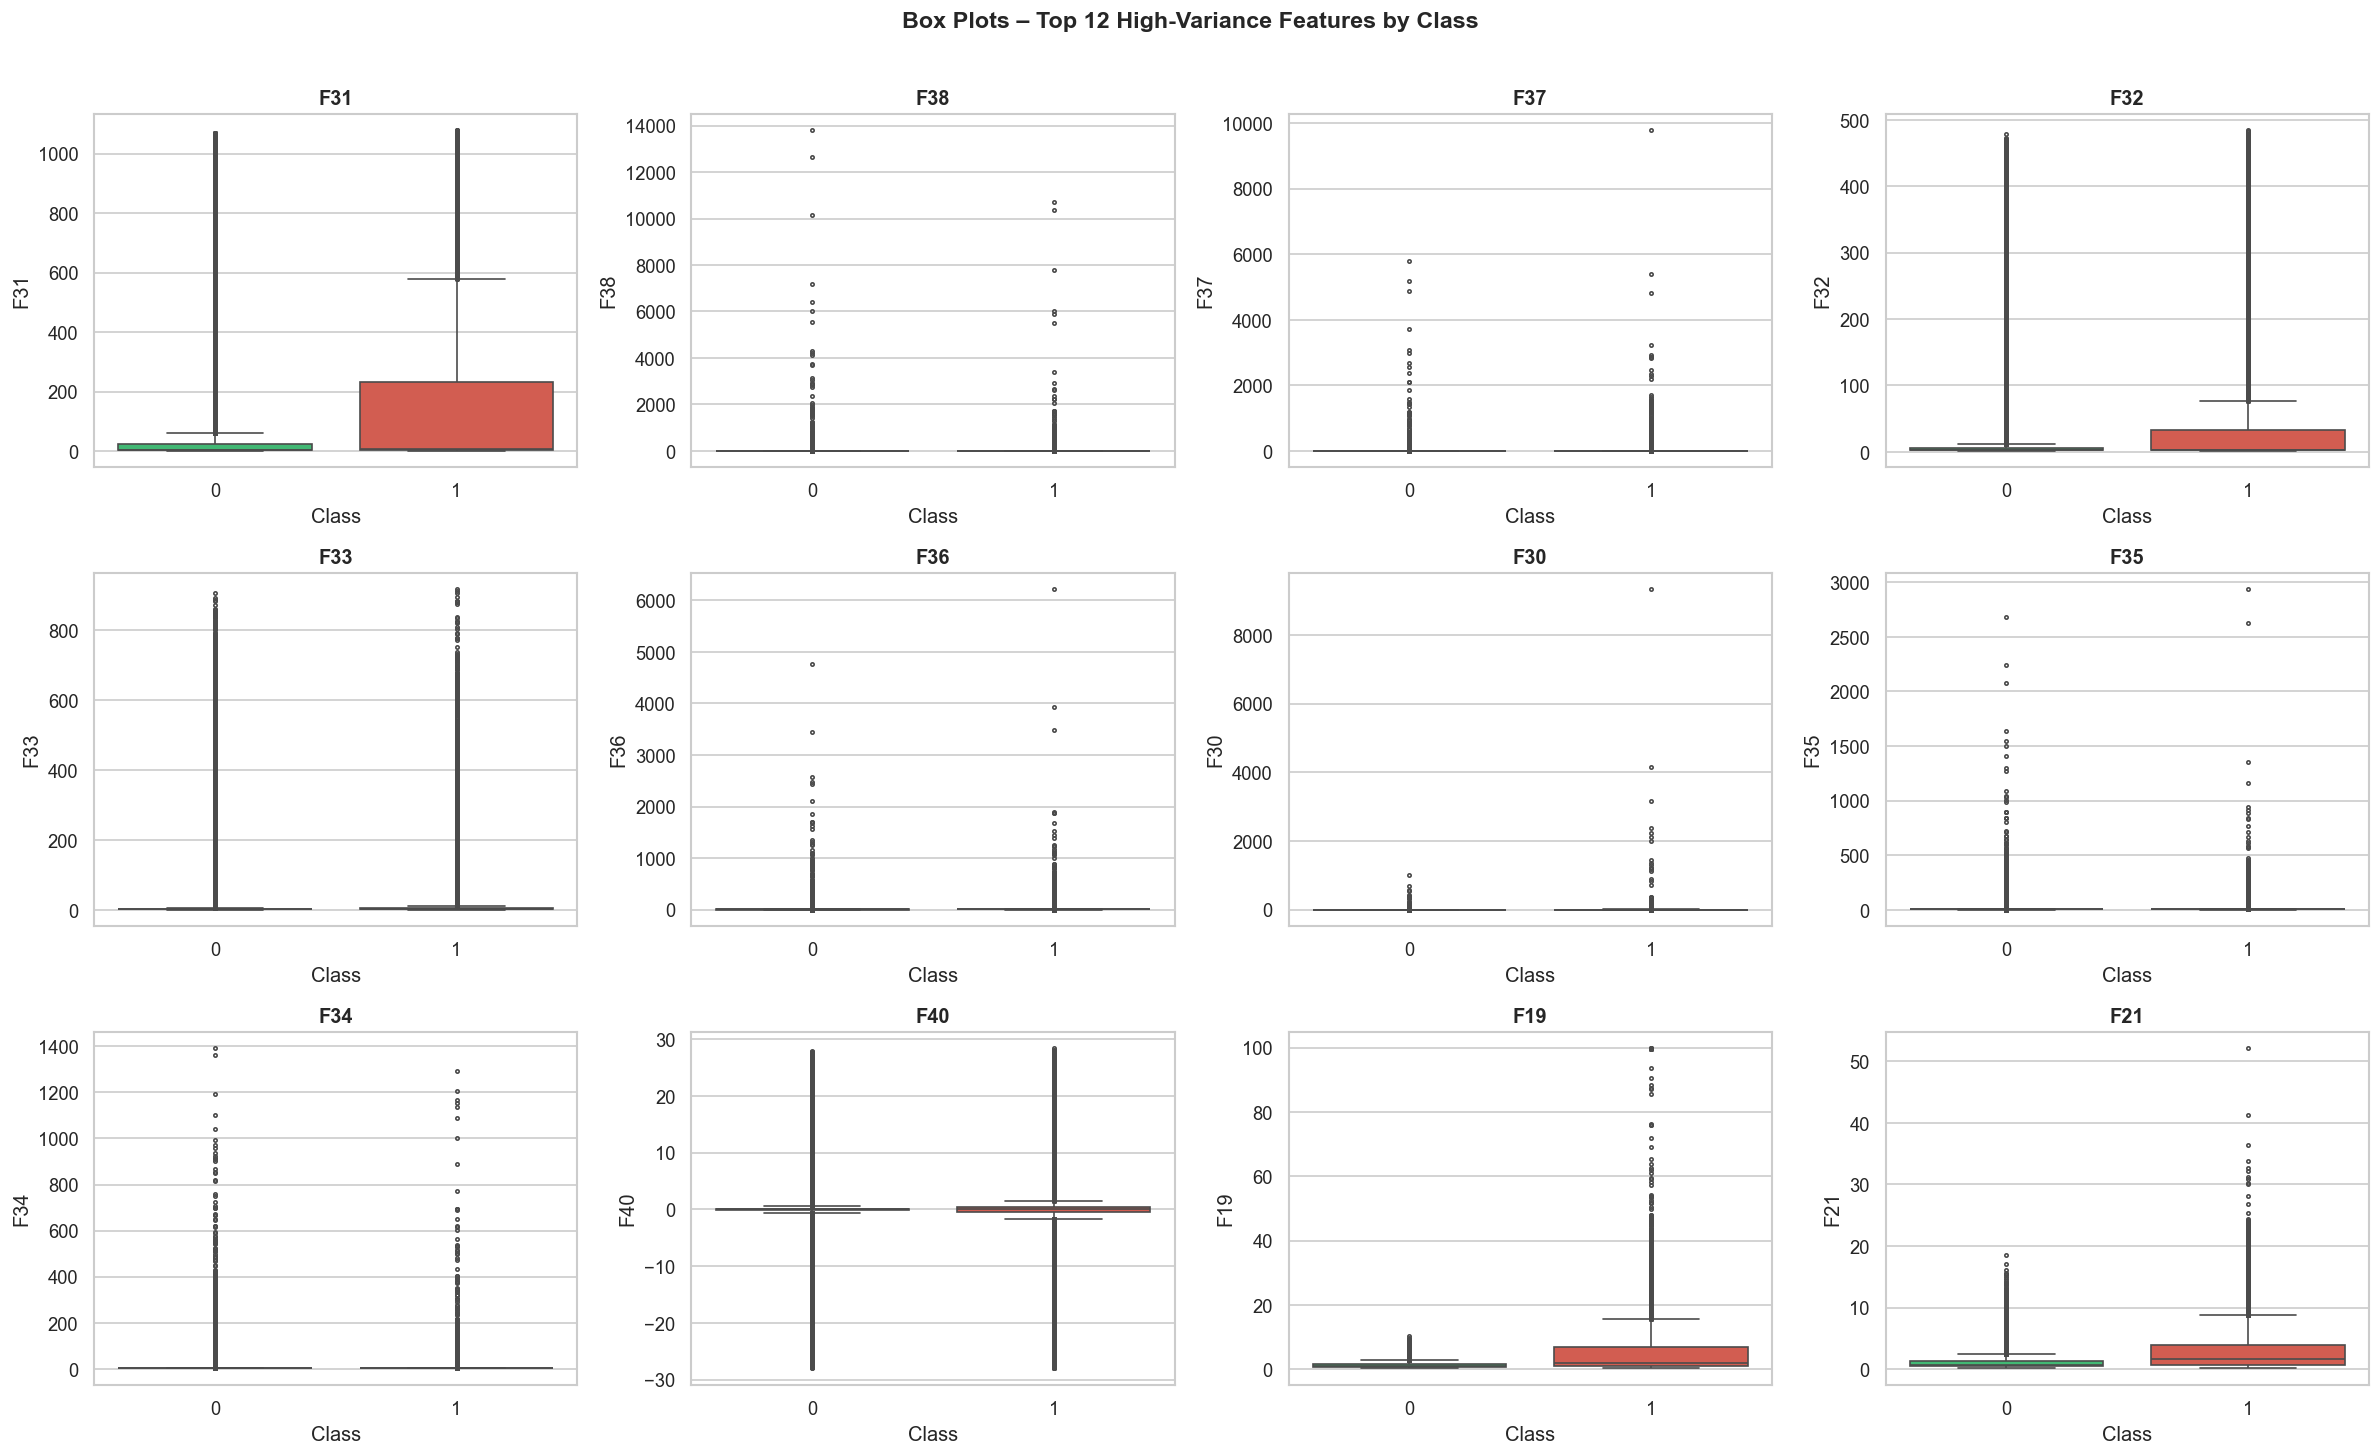

In [149]:
#Box plots for outlier detection (top 12 features by variance)
top_var = train_df[feature_cols].var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(top_var):
    sns.boxplot(data=train_df, x='Class', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], fliersize=2)
    axes[i].set_title(col, fontweight='bold')

fig.suptitle("Box Plots – Top 12 High-Variance Features by Class", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

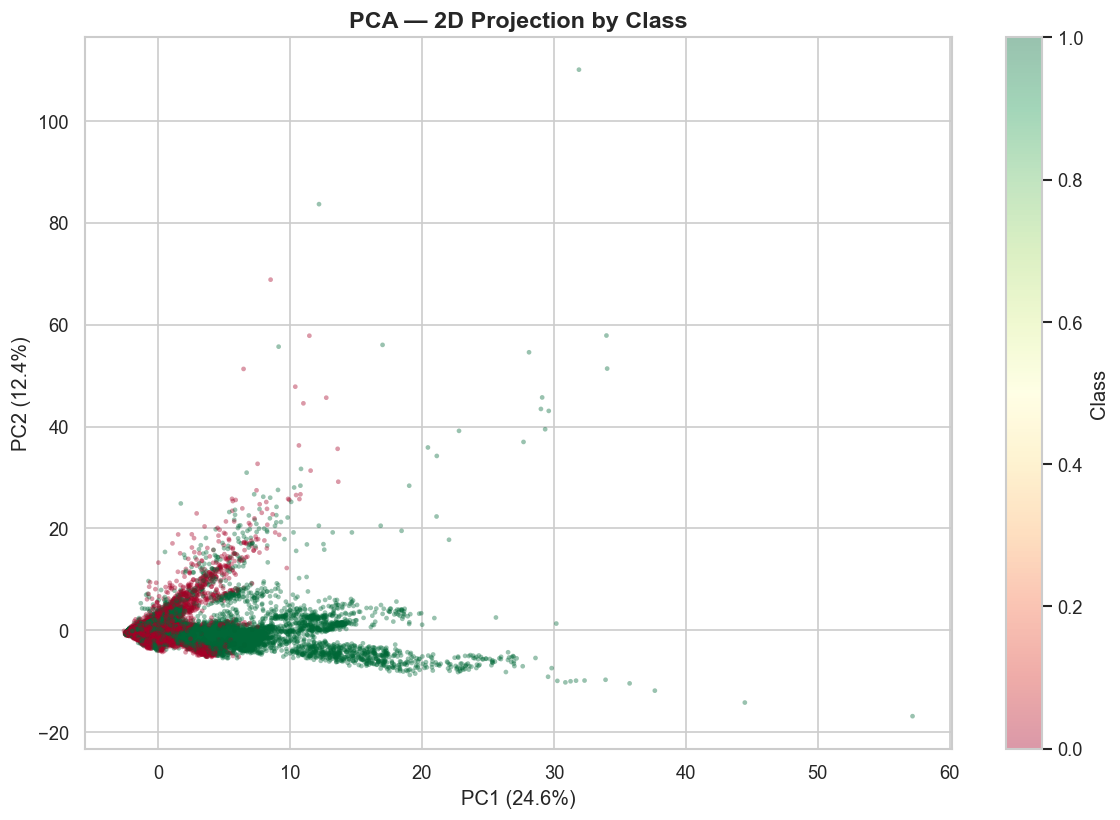

Explained variance (2 components): 36.9%


In [150]:
# PCA 2D Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_df[feature_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=train_df['Class'], cmap='RdYlGn', alpha=0.4, s=8, edgecolors='none')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — 2D Projection by Class", fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

print(f"Explained variance (2 components): {sum(pca.explained_variance_ratio_)*100:.1f}%")

### Test Data

In [133]:
test_path = "Dataset/Test.csv"
test_df = pd.read_csv(test_path)

printf(test_df.head(5),title = "Data preview")
printf(test_df.describe(), title="Description")
printf(test_df.isnull().sum(),title = "Null Values")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Data preview <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃    ID       F01       F02       F03       F04       F05       F06       F07  \                                  ┃
┃ 0   1  0.277497  0.011515  0.009359  0.011706  0.015613  0.063679  0.021114                                     ┃
┃ 1   2  0.158754  0.013861  0.020935  0.002451  0.005939  0.006830  0.006934                                     ┃
┃ 2   3  0.504418  0.009106  0.007395  0.009073  0.029486  0.086782  0.122499                                     ┃
┃ 3   4  0.556345  0.005370  0.005670  0.005167  0.013731  0.014570  0.014776                                     ┃
┃ 4   5  0.128356  0.010014  0.016144  0.003891  0.004472  0.005297  0.007538                                     ┃
┃                                                                                                                 ┃
┃         F08       F09  ...       F38       F39        F40       F41       F42  \                                ┃
┃ 0  0.152000  0.220904  ...  2.974426  0.009399   0.015668  0.001999 -0.000937                                   ┃
┃ 1  0.117209  0.103432  ...  2.619811  0.029324  -0.003211  0.037691 -0.083697                                   ┃
┃ 2  0.179376  0.445695  ...  4.411972 -0.171520  -0.866895 -0.070657  0.034070                                   ┃
┃ 3  0.522296  0.189882  ...  2.709162  0.044236  19.880789 -2.144453 -1.792552                                   ┃
┃ 4  0.075874  0.101176  ...  2.872020 -0.056908   0.006535  0.070059 -0.007989                                   ┃
┃                                                                                                                 ┃
┃         F43       F44       F45       F46       F47                                                             ┃
┃ 0  0.010605 -0.001117  0.043216 -0.000077 -0.040124                                                             ┃
┃ 1  0.006595  0.044507  0.007523 -0.000283 -0.007837                                                             ┃
┃ 2 -0.000493 -0.011417 -0.004844 -0.034235 -0.001832                                                             ┃
┃ 3 -0.034137 -0.051971 -0.085069 -0.000110  0.045889                                                             ┃
┃ 4  0.004089 -0.000206 -0.011331  0.000441 -0.025263                                                             ┃
┃                                                                                                                 ┃
┃ [5 rows x 48 columns]                                                                                           ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Description <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                  ID           F01           F02           F03           F04  \                                  ┃
┃ count  10944.000000  10944.000000  10944.000000  10944.000000  10944.000000                                     ┃
┃ mean    5472.500000      0.564642      0.014021      0.015287      0.025999                                     ┃
┃ std     3159.405007      0.730968      0.019153      0.021543      0.048241                                     ┃
┃ min        1.000000      0.100015      0.003001      0.000844      0.000779                                     ┃
┃ 25%     2736.750000      0.199884      0.004736      0.005386      0.006256                                     ┃
┃ 50%     5472.500000      0.290166      0.007884      0.008893      0.012352                                     ┃
┃ 75%     8208.250000      0.533199      0.014022      0.016390      0.027621                                     ┃
┃ max    10944.000000     12.464613      0.197171      0.500112      0.768163                                     ┃
┃                                                                                                                 ┃
┃                 F05           F06           F07           F08           F09  \                                  ┃
┃ count  10944.000000  10944.000000  10944.000000  10944.000000  10944.000000                                     ┃
┃ mean       0.085579      0.155945      0.147610      0.253011      0.361478                                     ┃
┃ std        0.179844      0.384066      0.320122      0.350019      0.442753                                     ┃
┃ min        0.000961      0.000876      0.000672      0.000469      0.000561                                     ┃
┃ 25%        0.012048      0.014193      0.015108      0.071398      0.130366                                     ┃
┃ 50%        0.023026      0.031780      0.029432      0.120825      0.214884                                     ┃
┃ 75%        0.061513      0.114151      0.117718      0.263634      0.385270                                     ┃
┃ max        4.292895      6.838200      6.574803      6.069624      5.175863                                     ┃
┃                                                                                                                 ┃
┃        ...           F38           F39           F40           F41  \                                           ┃
┃ count  ...  10944.000000  10944.000000  10944.000000  10944.000000                                              ┃
┃ mean   ...     10.307742      0.018808     -0.067428      0.012258                                              ┃
┃ std    ...    189.279995      0.457887      8.537983      1.633478                                              ┃
┃ min    ...      1.561008     -5.861718    -27.894955     -9.605550                                              ┃
┃ 25%    ...      2.692958     -0.036139     -0.275113     -0.115780                                              ┃
┃ 50%    ...      2.938494      0.000092     -0.000753     -0.001821                                              ┃
┃ 75%    ...      3.253866      0.043703      0.159826      0.112382                                              ┃
┃ max    ...  15791.123050     35.719830     28.052998     11.274732                                              ┃
┃                                                                                                                 ┃
┃                 F42           F43           F44           F45           F46  \                                  ┃
┃ count  10944.000000  10944.000000  10944.000000  10944.000000  10944.000000                                     ┃
┃ mean       0.009616      0.002767      0.002355      0.002160      0.007295                                     ┃
┃ std        1.098110      0.352750      0.221111      0

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Null Values <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ID     0                                                                                                        ┃
┃ F01    0                                                                                                        ┃
┃ F02    0                                                                                                        ┃
┃ F03    0                                                                                                        ┃
┃ F04    0                                                                                                        ┃
┃ F05    0                                                                                                        ┃
┃ F06    0                                                                                                        ┃
┃ F07    0                                                                                                        ┃
┃ F08    0                                                                                                        ┃
┃ F09    0                                                                                                        ┃
┃ F10    0                                                                                                        ┃
┃ F11    0                                                                                                        ┃
┃ F12    0                                                                                                        ┃
┃ F13    0                                                                                                        ┃
┃ F14    0                                                                                                        ┃
┃ F15    0                                                                                                        ┃
┃ F16    0                                                                                                        ┃
┃ F17    0                                                                                                        ┃
┃ F18    0                                                                                                        ┃
┃ F19    0                                                                                                        ┃
┃ F20    0                                                                                                        ┃
┃ F21    0                                                                                                        ┃
┃ F22    0                                                                                                        ┃
┃ F23    0                                                                                                        ┃
┃ F24    0                                                                                                        ┃
┃ F25    0                                                                                                        ┃
┃ F26    0                                                                                                        ┃
┃ F27    0                                                                                                        ┃
┃ F28    0                                                                                                        ┃
┃ F29    0                                                                                                        ┃
┃ F30    0                                                                                                        ┃
┃ F31    0                                                                                                        ┃
┃ F32    0                                                                                                        ┃
┃ F33    0                                              

In [134]:

# Display Basic Info 
temp =""
temp+= f"Shape : {train_df.shape}\n"
temp+= f"Duplicate rows: {train_df.duplicated().sum()}\n"
missing = train_df.isnull().sum()
if (missing.sum() > 0):
    temp+= str(missing[missing > 0]) +"\n"
else :
    temp +="No missing values ✅\n"
temp+= f"Total missing cells: {missing.sum()}"
printf(temp, title=">>> Basic Info <<<")


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> >>> Basic Info <<< <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Shape : (43776, 48)                                                                                             ┃
┃ Duplicate rows: 738                                                                                             ┃
┃ No missing values ✅                                                                                            ┃
┃ Total missing cells: 0                                                                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [135]:
# Class Distribution 

printf(train_df['Class'].value_counts().to_string(),f"\nClass ratio (0:1) = 1:{train_df['Class'].value_counts()[1] / train_df['Class'].value_counts()[0]:.2f}",title="Class Distribution")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> Class Distribution <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Class                                                                                                           ┃
┃ 0    26465                                                                                                      ┃
┃ 1    17311                                                                                                      ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃                                                                                                                 ┃
┃ Class ratio (0:1) = 1:0.65                                                                                      ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

## Preprocessing & Feature Engineering

In [165]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

from matplotlib.patches import Patch

In [ ]:
# Separate the features, target, and test IDs 
feature_cols = [c for c in train_df.columns if c not in ['ID', 'Class']]

X = train_df[feature_cols].copy()
y = train_df['Class'].copy()
X_test = test_df[feature_cols].copy()
test_ids = test_df['ID'].copy()

printf(f"X shape: {X.shape}\ny shape: {y.shape}\nX_test shape : {X_test.shape}\nFeatures: {len(feature_cols)}")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ X shape: (43776, 47)                                                                                            ┃
┃ y shape: (43776,)                                                                                               ┃
┃ X_test shape : (10944, 47)                                                                                      ┃
┃ Features: 47                                                                                                    ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [ ]:
# Handle missing values, if present in the traning data
missing_train = X.isnull().sum().sum()
missing_test = X_test.isnull().sum().sum()

printf(f"Missing in TRAIN: {missing_train}\nMissing in TEST : {missing_test}")

if missing_train > 0 or missing_test > 0:
    # fill missing value with the median 
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)
    print("✅ Missing values imputed with median")
else:
    print("✅ No missing values — skipping imputation")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Missing in TRAIN: 0                                                                                             ┃
┃ Missing in TEST : 0                                                                                             ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

✅ No missing values — skipping imputation


In [161]:
#Remove duplicate rows present in the training data
before = X.shape[0]
mask = ~train_df.duplicated()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)
after = X.shape[0]

printf(f"Rows before: {before}\nRows after : {after}\nRemoved    : {before - after} duplicates")

C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\3045111424.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = X[mask].reset_index(drop=True)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Rows before: 43038                                                                                              ┃
┃ Rows after : 42321                                                                                              ┃
┃ Removed    : 717 duplicates                                                                                     ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [162]:
# Drop highly correlated redundant features (|r| > 0.95)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]

X.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)
feature_cols = [c for c in feature_cols if c not in drop_cols]

printf(f"Features with |r| > 0.95 to drop: {drop_cols}\n✅ Remaining features: {len(feature_cols)}")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Features with |r| > 0.95 to drop: ['F24', 'F25', 'F26', 'F27', 'F28', 'F29']                                    ┃
┃ ✅ Remaining features: 41                                                                                       ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [163]:
# Feature Engineering: Row-wise statistical features
def add_stat_features(df, feat_cols):
    df = df.copy()
    df['stat_mean']   = df[feat_cols].mean(axis=1)
    df['stat_std']    = df[feat_cols].std(axis=1)
    df['stat_min']    = df[feat_cols].min(axis=1)
    df['stat_max']    = df[feat_cols].max(axis=1)
    df['stat_range']  = df['stat_max'] - df['stat_min']
    df['stat_median'] = df[feat_cols].median(axis=1)
    df['stat_skew']   = df[feat_cols].skew(axis=1)
    df['stat_kurt']   = df[feat_cols].kurtosis(axis=1)
    df['stat_q25']    = df[feat_cols].quantile(0.25, axis=1)
    df['stat_q75']    = df[feat_cols].quantile(0.75, axis=1)
    df['stat_iqr']    = df['stat_q75'] - df['stat_q25']
    return df

X = add_stat_features(X, feature_cols)
X_test = add_stat_features(X_test, feature_cols)

new_cols = [c for c in X.columns if c.startswith('stat_')]
printf(f"✅ Added {len(new_cols)} statistical features: {new_cols}\nTotal features now: {X.shape[1]}")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ✅ Added 11 statistical features: ['stat_mean', 'stat_std', 'stat_min', 'stat_max', 'stat_range',               ┃
┃ 'stat_median', 'stat_skew', 'stat_kurt', 'stat_q25', 'stat_q75', 'stat_iqr']                                    ┃
┃ Total features now: 52                                                                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [164]:
#Feature Engineering: Top interaction features
# Use top features correlated with target to create interaction pairs
target_corr = X.corrwith(y).abs().sort_values(ascending=False)
top_features = target_corr.head(10).index.tolist()

interaction_cols = []
for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        f1, f2 = top_features[i], top_features[j]
        # multiply
        col_name = f"{f1}_x_{f2}"
        X[col_name] = X[f1] * X[f2]
        X_test[col_name] = X_test[f1] * X_test[f2]
        interaction_cols.append(col_name)
        # ratio (safe division)
        col_name_r = f"{f1}_div_{f2}"
        X[col_name_r] = X[f1] / (X[f2] + 1e-8)
        X_test[col_name_r] = X_test[f1] / (X_test[f2] + 1e-8)
        interaction_cols.append(col_name_r)

printf(f"✅ Added {len(interaction_cols)} interaction features\nTotal features now: {X.shape[1]}")

C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\10772584.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col_name] = X[f1] * X[f2]
C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\10772584.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[col_name] = X_test[f1] * X_test[f2]
C:\Users\devdh\AppData\Local\Temp\ipykernel_3584\10772584.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ✅ Added 90 interaction features                                                                                ┃
┃ Total features now: 142                                                                                         ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

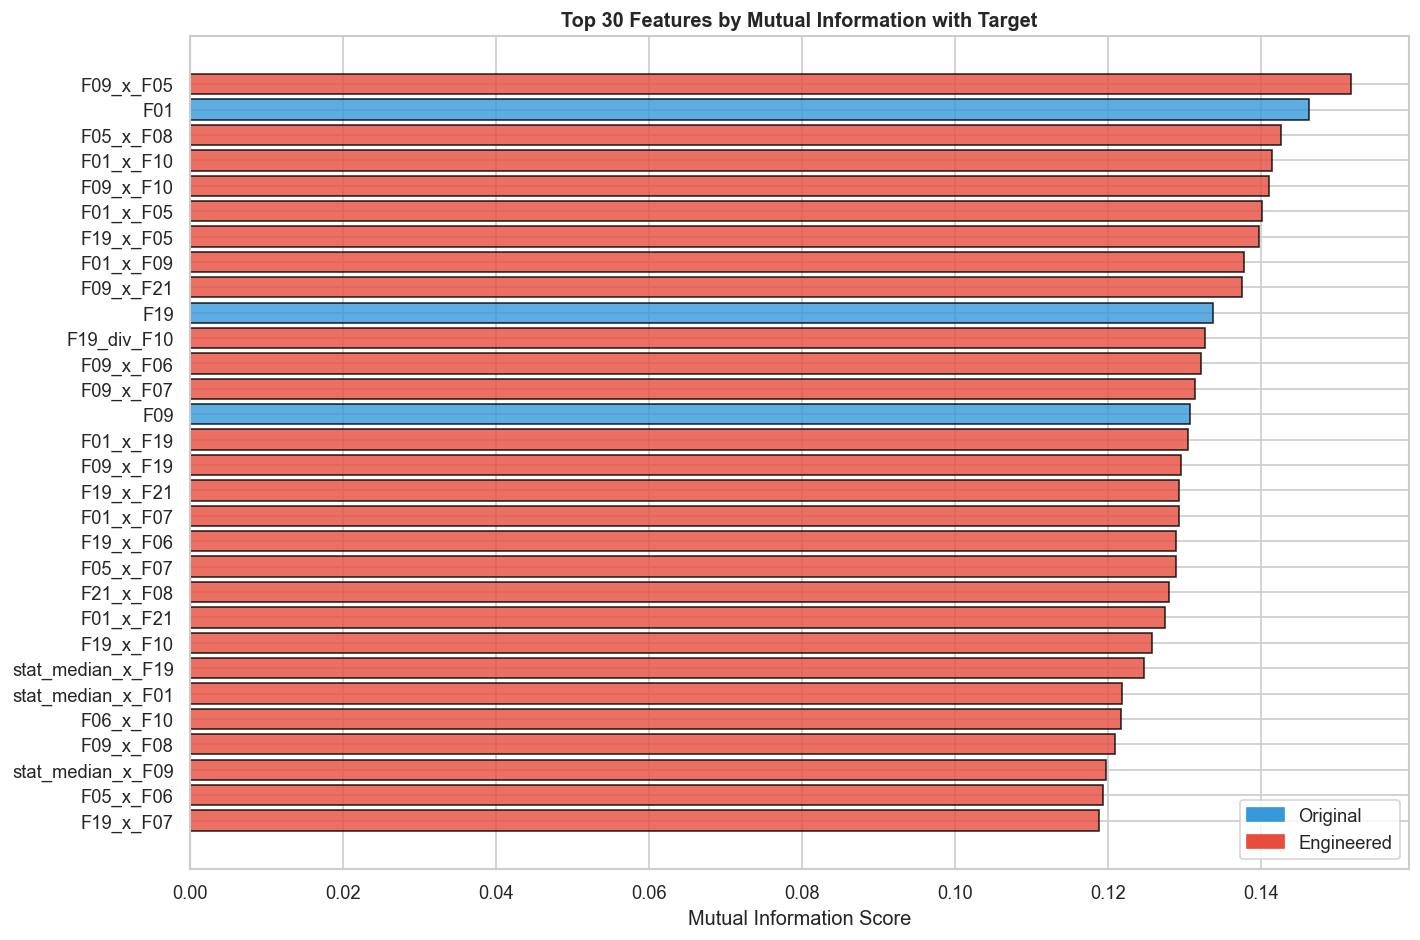


Bottom 10 features (candidates for removal):
            Feature  MI_Score
                F40  0.013748
                F41  0.013137
                F44  0.012753
        F09_div_F21  0.012649
stat_median_div_F08  0.012520
                F11  0.010805
           stat_min  0.010594
                F42  0.009532
                F39  0.008850
                F45  0.001049


In [166]:
# Mutual Information scores to validate feature quality
mi_scores = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

# Visualize top 30
fig, ax = plt.subplots(figsize=(12, 8))
top30 = mi_df.head(30)
colors = ['#e74c3c' if f.startswith('stat_') or '_x_' in f or '_div_' in f else '#3498db' for f in top30['Feature']]
ax.barh(top30['Feature'][::-1], top30['MI_Score'][::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 30 Features by Mutual Information with Target", fontweight='bold')

# Legend
ax.legend(handles=[Patch(color='#3498db', label='Original'),
                   Patch(color='#e74c3c', label='Engineered')], loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nBottom 10 features (candidates for removal):")
print(mi_df.tail(10).to_string(index=False))

In [167]:
#Drop zero/near-zero MI features
low_mi = mi_df[mi_df['MI_Score'] < 0.001]['Feature'].tolist()
print(f"Features with MI < 0.001: {len(low_mi)} → {low_mi}")

if low_mi:
    X.drop(columns=low_mi, inplace=True)
    X_test.drop(columns=low_mi, inplace=True)
    printf(f"✅ Dropped. Remaining features: {X.shape[1]}")
else:
    printf("✅ All features have meaningful MI — keeping all")

Features with MI < 0.001: 0 → []


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>>  <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ✅ All features have meaningful MI — keeping all                                                                ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

In [168]:
# Scale features with RobustScaler
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"✅ Scaling done with RobustScaler")
print(f"Train mean range : [{X_scaled.mean().min():.4f}, {X_scaled.mean().max():.4f}]")
print(f"Train std range  : [{X_scaled.std().min():.4f}, {X_scaled.std().max():.4f}]")

✅ Scaling done with RobustScaler
Train mean range : [-1.8556, 12.1373]
Train std range  : [0.5171, 310.7946]


In [169]:
# Train / Validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train class dist:\n{y_train.value_counts().to_string()}")
print(f"y_val   class dist:\n{y_val.value_counts().to_string()}")

X_train : (33856, 142)
X_val   : (8465, 142)
y_train class dist:
Class
0    20239
1    13617
y_val   class dist:
Class
0    5060
1    3405


In [ ]:
#Final summary before modeling

printf( f"Original features      : 47",
    f"Dropped (corr > 0.95)  : {len(drop_cols)}",
    f"Added stat features    : {len(new_cols)}",
    f"Added interactions     : {len(interaction_cols)}",
    f"Dropped (low MI)       : {len(low_mi)}",
    f"Final feature count    : {X_scaled.shape[1]}",
    f"Training samples       : {X_train.shape[0]}",
    f"Validation samples     : {X_val.shape[0]}",
    f"Test samples           : {X_test_scaled.shape[0]}",
    f"Scaler                 : RobustScaler",
    title="PREPROCESSING COMPLETE — SUMMARY")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ >>> PREPROCESSING COMPLETE — SUMMARY <<< ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Original features      : 47                                                                                     ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Dropped (corr > 0.95)  : 6                                                                                      ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Added stat features    : 11                                                                                     ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Added interactions     : 90                                                                                     ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Dropped (low MI)       : 0                                                                                      ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Final feature count    : 142                                                                                    ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Training samples       : 33856                                                                                  ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Validation samples     : 8465                                                                                   ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Test samples           : 10944                                                                                  ┃
┃ ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── ┃
┃ Scaler                 : RobustScaler                                                                           ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

## Model Traning

In [171]:
# Cell 34 - Model Training Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb
import time

In [172]:
# Cell 35 - Helper: Evaluate and store model results
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, store=True):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_v)
    y_prob = model.predict_proba(X_v)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    metrics = {
        'Accuracy':  accuracy_score(y_v, y_pred),
        'F1':        f1_score(y_v, y_pred),
        'Precision': precision_score(y_v, y_pred),
        'Recall':    recall_score(y_v, y_pred),
        'AUC-ROC':   roc_auc_score(y_v, y_prob),
        'Time (s)':  round(train_time, 2),
    }

    if store:
        results[name] = metrics

    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")
    print(f"\n{classification_report(y_v, y_pred, target_names=['Class 0', 'Class 1'])}")

    return model, y_pred, y_prob

In [173]:
# Baseline: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model, lr_pred, lr_prob = evaluate_model(
    "Logistic Regression", lr_model, X_train, y_train, X_val, y_val
)


  Logistic Regression
  Accuracy    : 0.8066
  F1          : 0.7431
  Precision   : 0.7980
  Recall      : 0.6952
  AUC-ROC     : 0.8676
  Time (s)    : 25.3100

              precision    recall  f1-score   support

     Class 0       0.81      0.88      0.84      5060
     Class 1       0.80      0.70      0.74      3405

    accuracy                           0.81      8465
   macro avg       0.80      0.79      0.79      8465
weighted avg       0.81      0.81      0.80      8465



C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [174]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model, rf_pred, rf_prob = evaluate_model(
    "Random Forest", rf_model, X_train, y_train, X_val, y_val
)


  Random Forest
  Accuracy    : 0.9800
  F1          : 0.9748
  Precision   : 0.9897
  Recall      : 0.9604
  AUC-ROC     : 0.9986
  Time (s)    : 169.2600

              precision    recall  f1-score   support

     Class 0       0.97      0.99      0.98      5060
     Class 1       0.99      0.96      0.97      3405

    accuracy                           0.98      8465
   macro avg       0.98      0.98      0.98      8465
weighted avg       0.98      0.98      0.98      8465



In [175]:
# XGBoost
# Calculate scale_pos_weight for class imbalance
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluate manually since we used early stopping in fit
y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

results['XGBoost'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_xgb),
    'F1':        f1_score(y_val, y_pred_xgb),
    'Precision': precision_score(y_val, y_pred_xgb),
    'Recall':    recall_score(y_val, y_pred_xgb),
    'AUC-ROC':   roc_auc_score(y_val, y_prob_xgb),
}

print(f"\n{'=' * 50}")
print(f"  XGBoost (early stopped at {xgb_model.best_iteration} rounds)")
print(f"{'=' * 50}")
for k, v in results['XGBoost'].items():
    print(f"  {k:<12}: {v:.4f}")
print(f"\n{classification_report(y_val, y_pred_xgb, target_names=['Class 0', 'Class 1'])}")


  XGBoost (early stopped at 998 rounds)
  Accuracy    : 0.9889
  F1          : 0.9862
  Precision   : 0.9885
  Recall      : 0.9838
  AUC-ROC     : 0.9989

              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      5060
     Class 1       0.99      0.98      0.99      3405

    accuracy                           0.99      8465
   macro avg       0.99      0.99      0.99      8465
weighted avg       0.99      0.99      0.99      8465



In [176]:
# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

y_pred_lgb = lgb_model.predict(X_val)
y_prob_lgb = lgb_model.predict_proba(X_val)[:, 1]

results['LightGBM'] = {
    'Accuracy':  accuracy_score(y_val, y_pred_lgb),
    'F1':        f1_score(y_val, y_pred_lgb),
    'Precision': precision_score(y_val, y_pred_lgb),
    'Recall':    recall_score(y_val, y_pred_lgb),
    'AUC-ROC':   roc_auc_score(y_val, y_prob_lgb),
}

print(f"\n{'=' * 50}")
print(f"  LightGBM (best iteration: {lgb_model.best_iteration_})")
print(f"{'=' * 50}")
for k, v in results['LightGBM'].items():
    print(f"  {k:<12}: {v:.4f}")
print(f"\n{classification_report(y_val, y_pred_lgb, target_names=['Class 0', 'Class 1'])}")


  LightGBM (best iteration: 934)
  Accuracy    : 0.9895
  F1          : 0.9869
  Precision   : 0.9902
  Recall      : 0.9836
  AUC-ROC     : 0.9992

              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      5060
     Class 1       0.99      0.98      0.99      3405

    accuracy                           0.99      8465
   macro avg       0.99      0.99      0.99      8465
weighted avg       0.99      0.99      0.99      8465



In [177]:
# Compare all models side by side
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1', ascending=False)

print("=" * 70)
print("               MODEL COMPARISON (sorted by F1)")
print("=" * 70)
print(results_df.to_string())

# Best model so far
best_name = results_df.index[0]
print(f"\n🏆 Best model so far: {best_name} (F1 = {results_df.loc[best_name, 'F1']:.4f})")

               MODEL COMPARISON (sorted by F1)
                     Accuracy        F1  Precision    Recall   AUC-ROC  Time (s)
LightGBM             0.989486  0.986887   0.990242  0.983554  0.999199       NaN
XGBoost              0.988895  0.986164   0.988492  0.983847  0.998902       NaN
Random Forest        0.980035  0.974810   0.989709  0.960352  0.998615    169.26
Logistic Regression  0.806615  0.743054   0.798045  0.695154  0.867571     25.31

🏆 Best model so far: LightGBM (F1 = 0.9869)


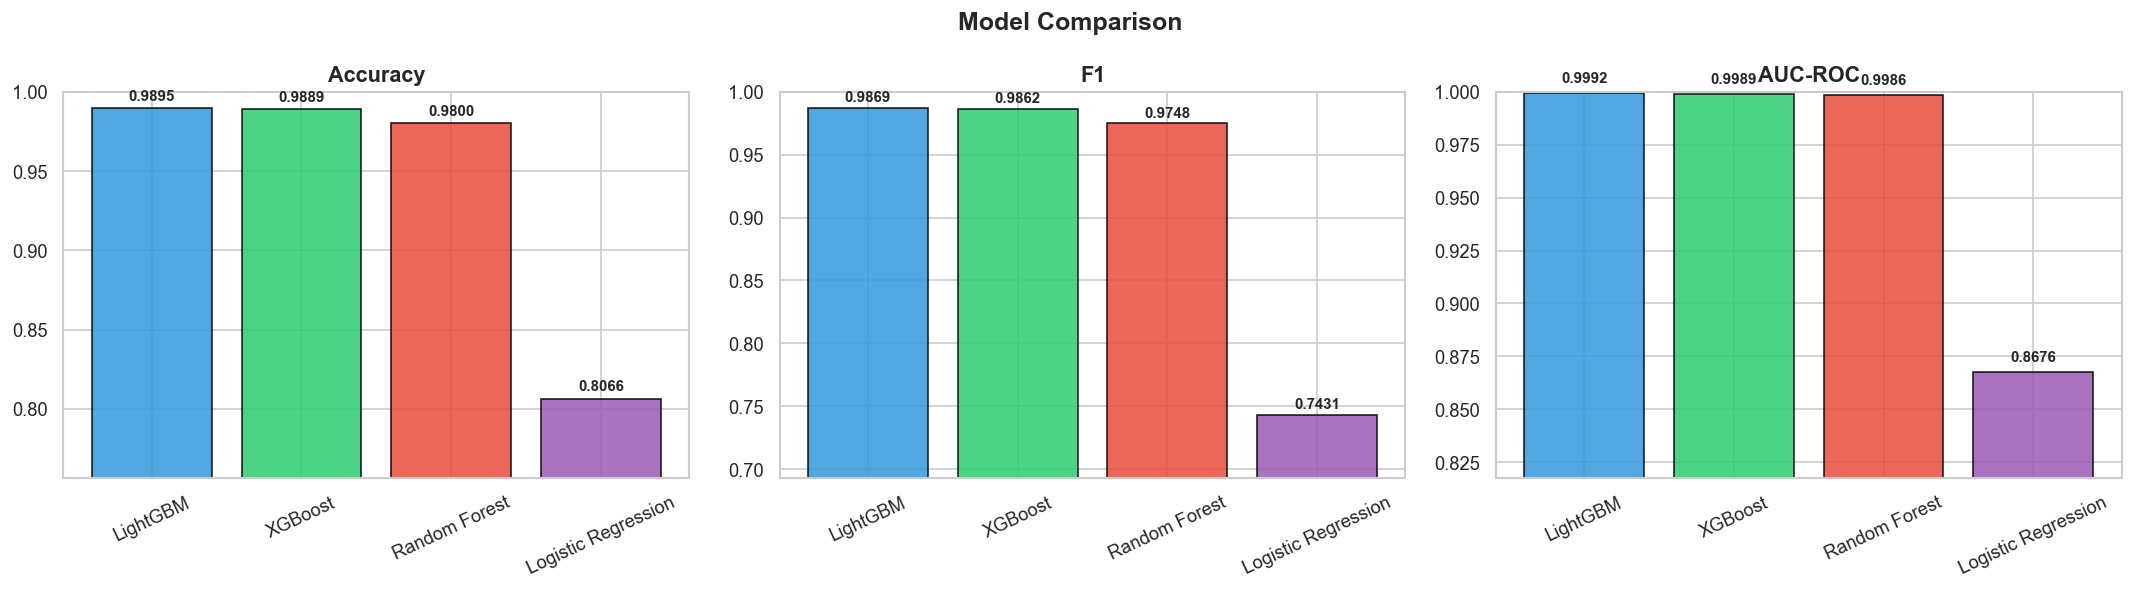

In [178]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['Accuracy', 'F1', 'AUC-ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    values = results_df[metric].values
    names = results_df.index
    bars = axes[idx].bar(names, values, color=colors[:len(names)], edgecolor='black', alpha=0.85)
    axes[idx].set_title(metric, fontweight='bold', fontsize=13)
    axes[idx].set_ylim(min(values) - 0.05, 1.0)
    axes[idx].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)

fig.suptitle("Model Comparison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

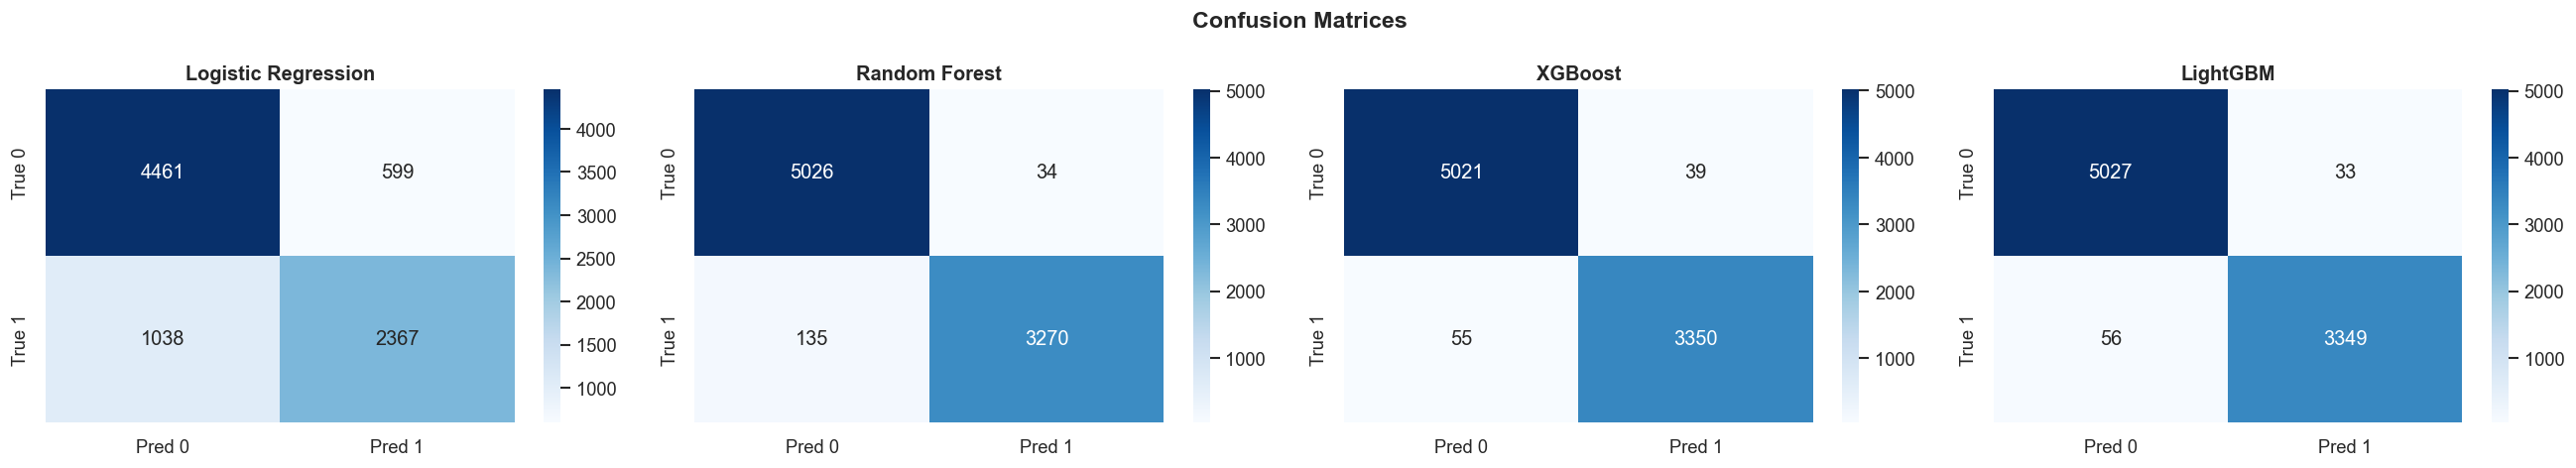

In [179]:
# Confusion Matrices side by side
model_preds = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb,
}

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for idx, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[idx].set_title(name, fontweight='bold')

fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warning

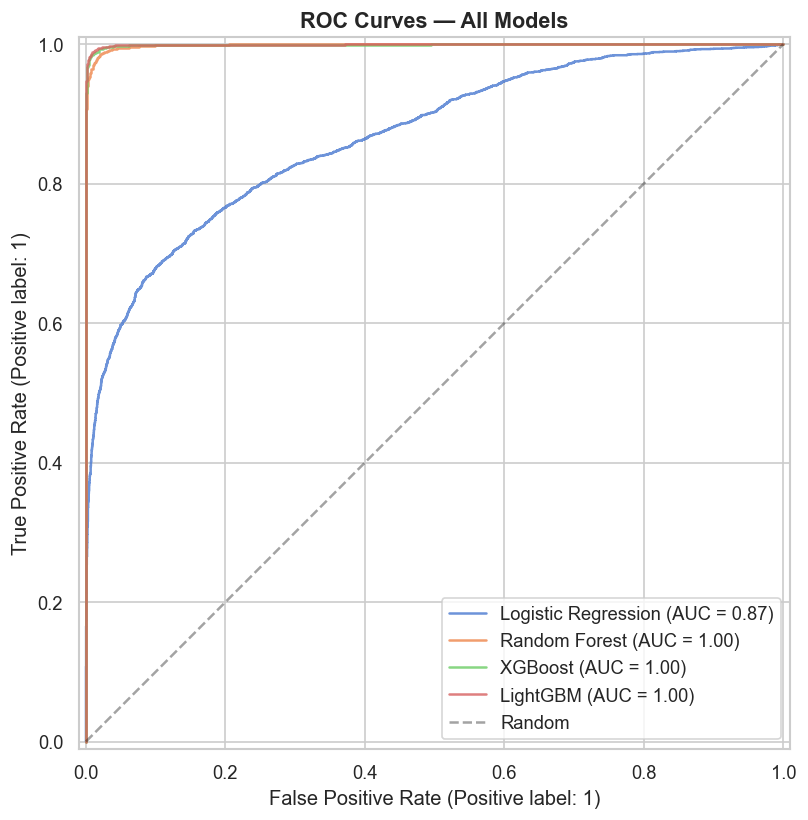

In [180]:
# ROC Curves overlay
fig, ax = plt.subplots(figsize=(9, 7))

model_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'XGBoost': y_prob_xgb,
    'LightGBM': y_prob_lgb,
}

for name, probs in model_probs.items():
    RocCurveDisplay.from_predictions(y_val, probs, name=name, ax=ax, alpha=0.8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_title("ROC Curves — All Models", fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

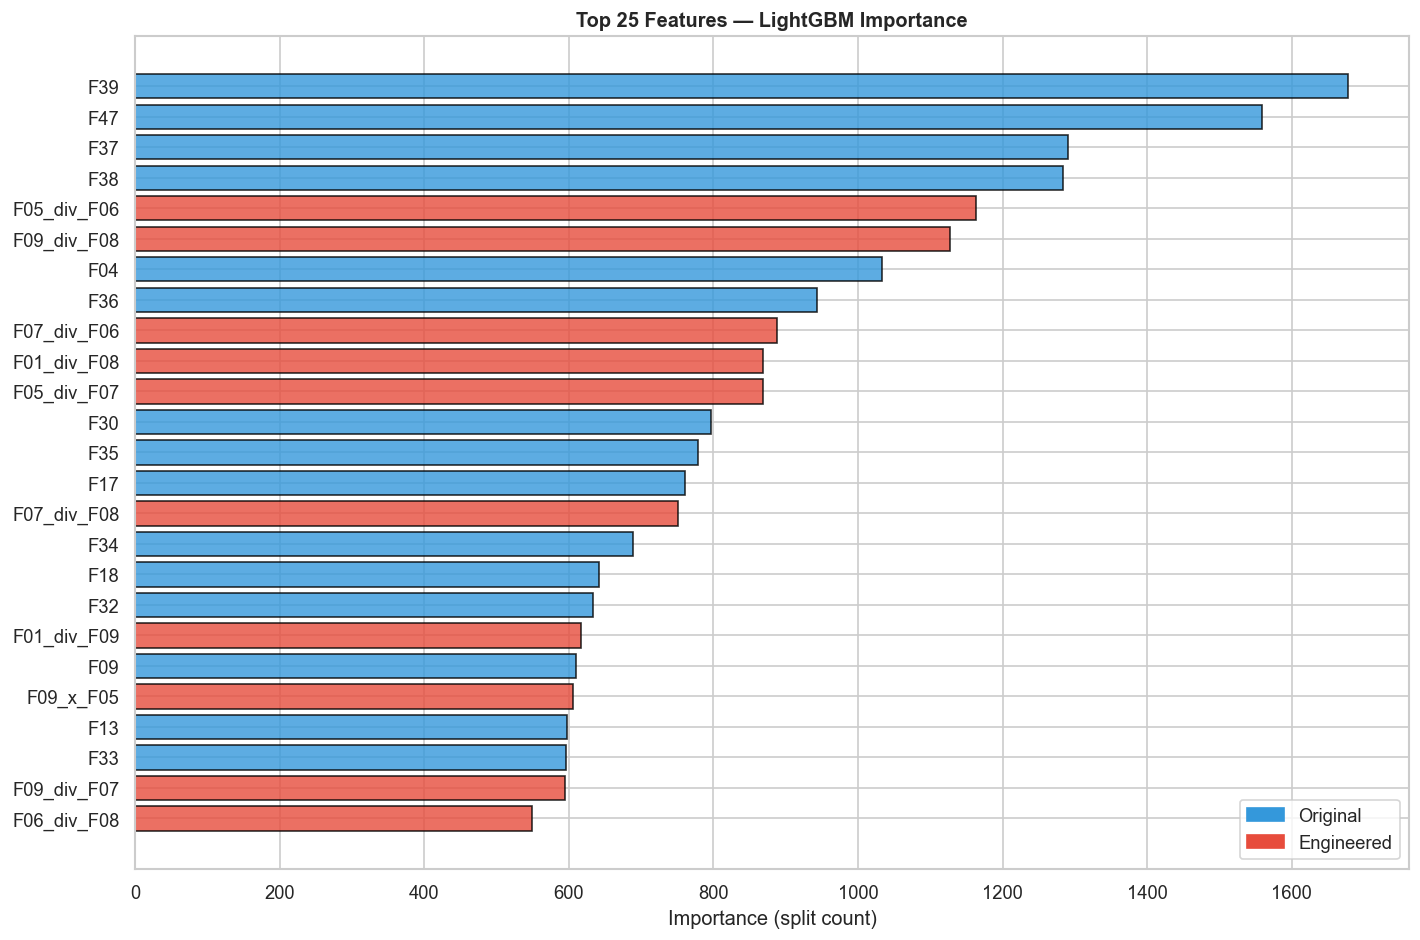

In [181]:
# Feature Importance (top 25 from best tree model)
# Use LightGBM importance (usually the best tree model)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top25 = importance.head(25)
colors = ['#e74c3c' if f.startswith('stat_') or '_x_' in f or '_div_' in f else '#3498db' for f in top25['Feature']]
ax.barh(top25['Feature'][::-1], top25['Importance'][::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel("Importance (split count)")
ax.set_title("Top 25 Features — LightGBM Importance", fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Original'),
                   Patch(color='#e74c3c', label='Engineered')], loc='lower right')
plt.tight_layout()
plt.show()

In [182]:
# Optuna Hyperparameter Tuning (LightGBM)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 2000),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in skf.split(X_scaled, y):
        X_tr, X_v = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
        y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(
            **params,
            is_unbalance=True,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_v, y_v)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        )
        preds = model.predict(X_v)
        f1_scores.append(f1_score(y_v, preds))

    return np.mean(f1_scores)

study = optuna.create_study(direction='maximize', study_name='lgbm-tuning')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f"\n🏆 Best F1 (5-fold CV): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

C:\Users\devdh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 25. Best value: 0.98813: 100%|██████████| 80/80 [4:19:33<00:00, 194.67s/it]   


🏆 Best F1 (5-fold CV): 0.9881
Best params:
  n_estimators: 1889
  max_depth: 12
  learning_rate: 0.03482743632073527
  num_leaves: 85
  subsample: 0.7686483726983346
  colsample_bytree: 0.7374775707078599
  min_child_samples: 44
  reg_alpha: 0.0715604903471464
  reg_lambda: 0.03350253251304945


In [183]:
# Optuna Tuning for XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 2000),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in skf.split(X_scaled, y):
        X_tr, X_v = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
        y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(
            **params,
            scale_pos_weight=scale_pw,
            eval_metric='logloss',
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        preds = model.predict(X_v)
        f1_scores.append(f1_score(y_v, preds))

    return np.mean(f1_scores)

study_xgb = optuna.create_study(direction='maximize', study_name='xgb-tuning')
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)

print(f"\n🏆 Best F1 (5-fold CV): {study_xgb.best_value:.4f}")
print(f"Best params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

Best trial: 79. Best value: 0.987332: 100%|██████████| 80/80 [17:07:16<00:00, 770.46s/it]    


🏆 Best F1 (5-fold CV): 0.9873
Best params:
  n_estimators: 1331
  max_depth: 12
  learning_rate: 0.04513684867088938
  subsample: 0.6113845408751714
  colsample_bytree: 0.738680986437055
  min_child_weight: 1
  gamma: 0.03731454340011051
  reg_alpha: 0.04251866743714622
  reg_lambda: 0.003612206546581027


In [184]:
# Train final tuned models on full train set & evaluate on val
# Tuned LightGBM
lgb_tuned = lgb.LGBMClassifier(
    **study.best_params,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

# Tuned XGBoost
xgb_tuned = xgb.XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Evaluate both
for name, model in [('LightGBM (tuned)', lgb_tuned), ('XGBoost (tuned)', xgb_tuned)]:
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]
    results[name] = {
        'Accuracy':  accuracy_score(y_val, preds),
        'F1':        f1_score(y_val, preds),
        'Precision': precision_score(y_val, preds),
        'Recall':    recall_score(y_val, preds),
        'AUC-ROC':   roc_auc_score(y_val, probs),
    }
    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    for k, v in results[name].items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"\n{classification_report(y_val, preds, target_names=['Class 0', 'Class 1'])}")


  LightGBM (tuned)
  Accuracy    : 0.9894
  F1          : 0.9867
  Precision   : 0.9914
  Recall      : 0.9821
  AUC-ROC     : 0.9992

              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      5060
     Class 1       0.99      0.98      0.99      3405

    accuracy                           0.99      8465
   macro avg       0.99      0.99      0.99      8465
weighted avg       0.99      0.99      0.99      8465


  XGBoost (tuned)
  Accuracy    : 0.9895
  F1          : 0.9869
  Precision   : 0.9917
  Recall      : 0.9821
  AUC-ROC     : 0.9993

              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      5060
     Class 1       0.99      0.98      0.99      3405

    accuracy                           0.99      8465
   macro avg       0.99      0.99      0.99      8465
weighted avg       0.99      0.99      0.99      8465



         FULL MODEL COMPARISON (sorted by F1)
                     Accuracy        F1  Precision    Recall   AUC-ROC  Time (s)
LightGBM             0.989486  0.986887   0.990242  0.983554  0.999199       NaN
XGBoost (tuned)      0.989486  0.986867   0.991696  0.982085  0.999340       NaN
LightGBM (tuned)     0.989368  0.986722   0.991402  0.982085  0.999195       NaN
XGBoost              0.988895  0.986164   0.988492  0.983847  0.998902       NaN
Random Forest        0.980035  0.974810   0.989709  0.960352  0.998615    169.26
Logistic Regression  0.806615  0.743054   0.798045  0.695154  0.867571     25.31

🏆 Best model: LightGBM (F1 = 0.9869, AUC = 0.9992)


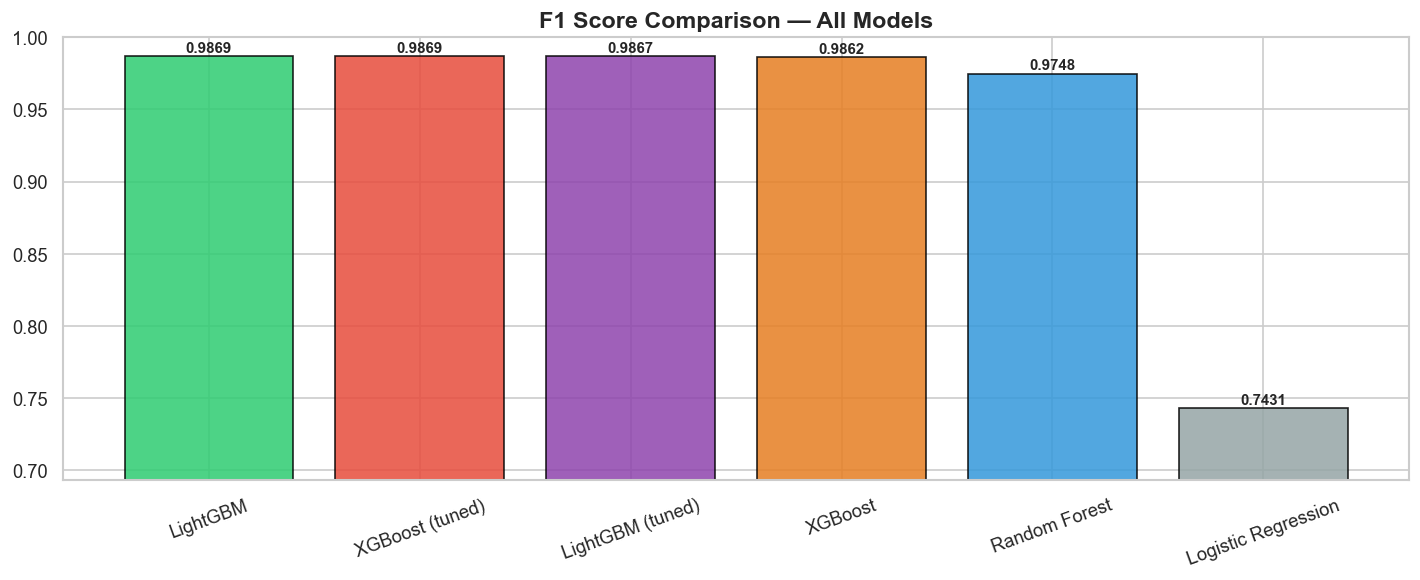

In [185]:
# Final comparison: all models including tuned
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)

print("=" * 70)
print("         FULL MODEL COMPARISON (sorted by F1)")
print("=" * 70)
print(results_df.to_string())

best_name = results_df.index[0]
print(f"\n🏆 Best model: {best_name} (F1 = {results_df.loc[best_name, 'F1']:.4f}, AUC = {results_df.loc[best_name, 'AUC-ROC']:.4f})")

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = {'Logistic Regression': '#95a5a6', 'Random Forest': '#3498db',
              'XGBoost': '#e67e22', 'LightGBM': '#2ecc71',
              'XGBoost (tuned)': '#e74c3c', 'LightGBM (tuned)': '#8e44ad'}
bar_colors = [colors_map.get(n, '#34495e') for n in results_df.index]
bars = ax.bar(results_df.index, results_df['F1'], color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, results_df['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)
ax.set_title("F1 Score Comparison — All Models", fontweight='bold', fontsize=14)
ax.set_ylim(results_df['F1'].min() - 0.05, 1.0)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

         FULL MODEL COMPARISON (sorted by F1)
                     Accuracy        F1  Precision    Recall   AUC-ROC  Time (s)
LightGBM             0.989486  0.986887   0.990242  0.983554  0.999199       NaN
XGBoost (tuned)      0.989486  0.986867   0.991696  0.982085  0.999340       NaN
LightGBM (tuned)     0.989368  0.986722   0.991402  0.982085  0.999195       NaN
XGBoost              0.988895  0.986164   0.988492  0.983847  0.998902       NaN
Random Forest        0.980035  0.974810   0.989709  0.960352  0.998615    169.26
Logistic Regression  0.806615  0.743054   0.798045  0.695154  0.867571     25.31

🏆 Best model: LightGBM (F1 = 0.9869, AUC = 0.9992)


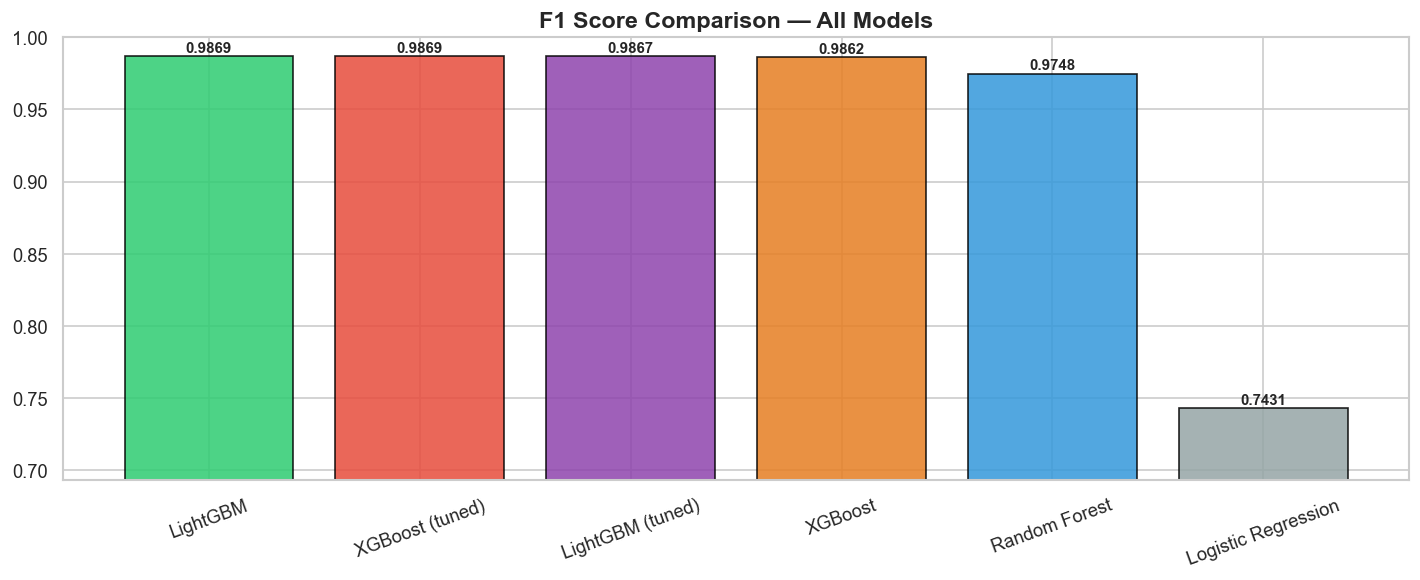

In [186]:
# Final comparison: all models including tuned
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)

print("=" * 70)
print("         FULL MODEL COMPARISON (sorted by F1)")
print("=" * 70)
print(results_df.to_string())

best_name = results_df.index[0]
print(f"\n🏆 Best model: {best_name} (F1 = {results_df.loc[best_name, 'F1']:.4f}, AUC = {results_df.loc[best_name, 'AUC-ROC']:.4f})")

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = {'Logistic Regression': '#95a5a6', 'Random Forest': '#3498db',
              'XGBoost': '#e67e22', 'LightGBM': '#2ecc71',
              'XGBoost (tuned)': '#e74c3c', 'LightGBM (tuned)': '#8e44ad'}
bar_colors = [colors_map.get(n, '#34495e') for n in results_df.index]
bars = ax.bar(results_df.index, results_df['F1'], color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, results_df['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)
ax.set_title("F1 Score Comparison — All Models", fontweight='bold', fontsize=14)
ax.set_ylim(results_df['F1'].min() - 0.05, 1.0)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [188]:
#Deep Learning Imports (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [189]:
# Prepare PyTorch datasets
# Convert to tensors
X_train_t = torch.FloatTensor(X_train.values)
y_train_t = torch.FloatTensor(y_train.values)
X_val_t   = torch.FloatTensor(X_val.values)
y_val_t   = torch.FloatTensor(y_val.values)
X_test_t  = torch.FloatTensor(X_test_scaled.values)

# Weighted sampler for class imbalance
class_counts = np.bincount(y_train.values.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train.values.astype(int)]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, torch.zeros(len(X_test_t)))  # dummy labels

train_loader = DataLoader(train_dataset, batch_size=512, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")
print(f"Input dim    : {X_train_t.shape[1]}")

Train batches: 67
Val batches  : 9
Test batches : 11
Input dim    : 142


In [190]:
# Define Neural Network Architecture
class FaultDetector(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),

            # Block 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),

            # Output
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim = X_train_t.shape[1]
model_nn = FaultDetector(input_dim, dropout=0.3).to(device)

# Count parameters
total_params = sum(p.numel() for p in model_nn.parameters())
trainable_params = sum(p.numel() for p in model_nn.parameters() if p.requires_grad)
print(f"Architecture:\n{model_nn}")
print(f"\nTotal params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Architecture:
FaultDetector(
  (net): Sequential(
    (0): Linear(in_features=142, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.15, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total params    : 80,833
Trainable params: 80,833


In [192]:
# Training setup
# pos_weight to handle class imbalance in loss
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

print(f"Loss         : BCEWithLogitsLoss (pos_weight={pos_weight.item():.2f})")
print(f"Optimizer    : Adam (lr=1e-3, wd=1e-4)")
print(f"Scheduler    : ReduceLROnPlateau (patience=5, factor=0.5)")

Loss         : BCEWithLogitsLoss (pos_weight=1.49)
Optimizer    : Adam (lr=1e-3, wd=1e-4)
Scheduler    : ReduceLROnPlateau (patience=5, factor=0.5)


In [193]:
# Training loop with early stopping
EPOCHS = 100
PATIENCE = 15

best_f1 = 0
best_epoch = 0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    # ---------- TRAIN ----------
    model_nn.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model_nn(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # ---------- VALIDATE ----------
    model_nn.eval()
    val_loss = 0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_nn(X_batch)
            val_loss += criterion(logits, y_batch).item() * len(X_batch)
            all_logits.append(logits.cpu())
            all_labels.append(y_batch.cpu())

    val_loss /= len(val_loader.dataset)
    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    val_probs = torch.sigmoid(all_logits).numpy()
    val_preds = (val_probs >= 0.5).astype(int)
    val_labels = all_labels.numpy().astype(int)

    val_f1  = f1_score(val_labels, val_preds)
    val_acc = accuracy_score(val_labels, val_preds)
    val_auc = roc_auc_score(val_labels, val_probs)
    current_lr = optimizer.param_groups[0]['lr']

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    # Scheduler step
    scheduler.step(val_f1)

    # Early stopping check
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        # Save best model weights
        best_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
    else:
        patience_counter += 1

    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1 or patience_counter == PATIENCE:
        print(f"Epoch {epoch:3d}/{EPOCHS} │ "
              f"Train Loss: {train_loss:.4f} │ "
              f"Val Loss: {val_loss:.4f} │ "
              f"F1: {val_f1:.4f} │ "
              f"Acc: {val_acc:.4f} │ "
              f"AUC: {val_auc:.4f} │ "
              f"LR: {current_lr:.6f} │ "
              f"{'⭐ BEST' if patience_counter == 0 else ''}")

    if patience_counter >= PATIENCE:
        print(f"\n⏹ Early stopping at epoch {epoch} — best F1 was {best_f1:.4f} at epoch {best_epoch}")
        break

# Reload best weights
model_nn.load_state_dict(best_state)
print(f"\n✅ Loaded best model from epoch {best_epoch} (F1={best_f1:.4f})")

Epoch   1/100 │ Train Loss: 0.7473 │ Val Loss: 0.6912 │ F1: 0.6589 │ Acc: 0.6540 │ AUC: 0.7931 │ LR: 0.001000 │ ⭐ BEST
Epoch   5/100 │ Train Loss: 0.5354 │ Val Loss: 0.5627 │ F1: 0.7156 │ Acc: 0.7171 │ AUC: 0.8811 │ LR: 0.001000 │ 
Epoch  10/100 │ Train Loss: 0.4617 │ Val Loss: 0.5355 │ F1: 0.7326 │ Acc: 0.7373 │ AUC: 0.9084 │ LR: 0.001000 │ 
Epoch  15/100 │ Train Loss: 0.4011 │ Val Loss: 0.5848 │ F1: 0.7279 │ Acc: 0.7187 │ AUC: 0.9154 │ LR: 0.000500 │ 
Epoch  20/100 │ Train Loss: 0.3820 │ Val Loss: 0.4117 │ F1: 0.7933 │ Acc: 0.8020 │ AUC: 0.9434 │ LR: 0.000500 │ ⭐ BEST
Epoch  25/100 │ Train Loss: 0.3572 │ Val Loss: 0.3568 │ F1: 0.8143 │ Acc: 0.8253 │ AUC: 0.9562 │ LR: 0.000500 │ 
Epoch  30/100 │ Train Loss: 0.3347 │ Val Loss: 0.3674 │ F1: 0.8088 │ Acc: 0.8195 │ AUC: 0.9552 │ LR: 0.000500 │ 
Epoch  35/100 │ Train Loss: 0.3189 │ Val Loss: 0.3165 │ F1: 0.8331 │ Acc: 0.8469 │ AUC: 0.9638 │ LR: 0.000250 │ ⭐ BEST
Epoch  40/100 │ Train Loss: 0.2961 │ Val Loss: 0.3067 │ F1: 0.8389 │ Acc: 0.85

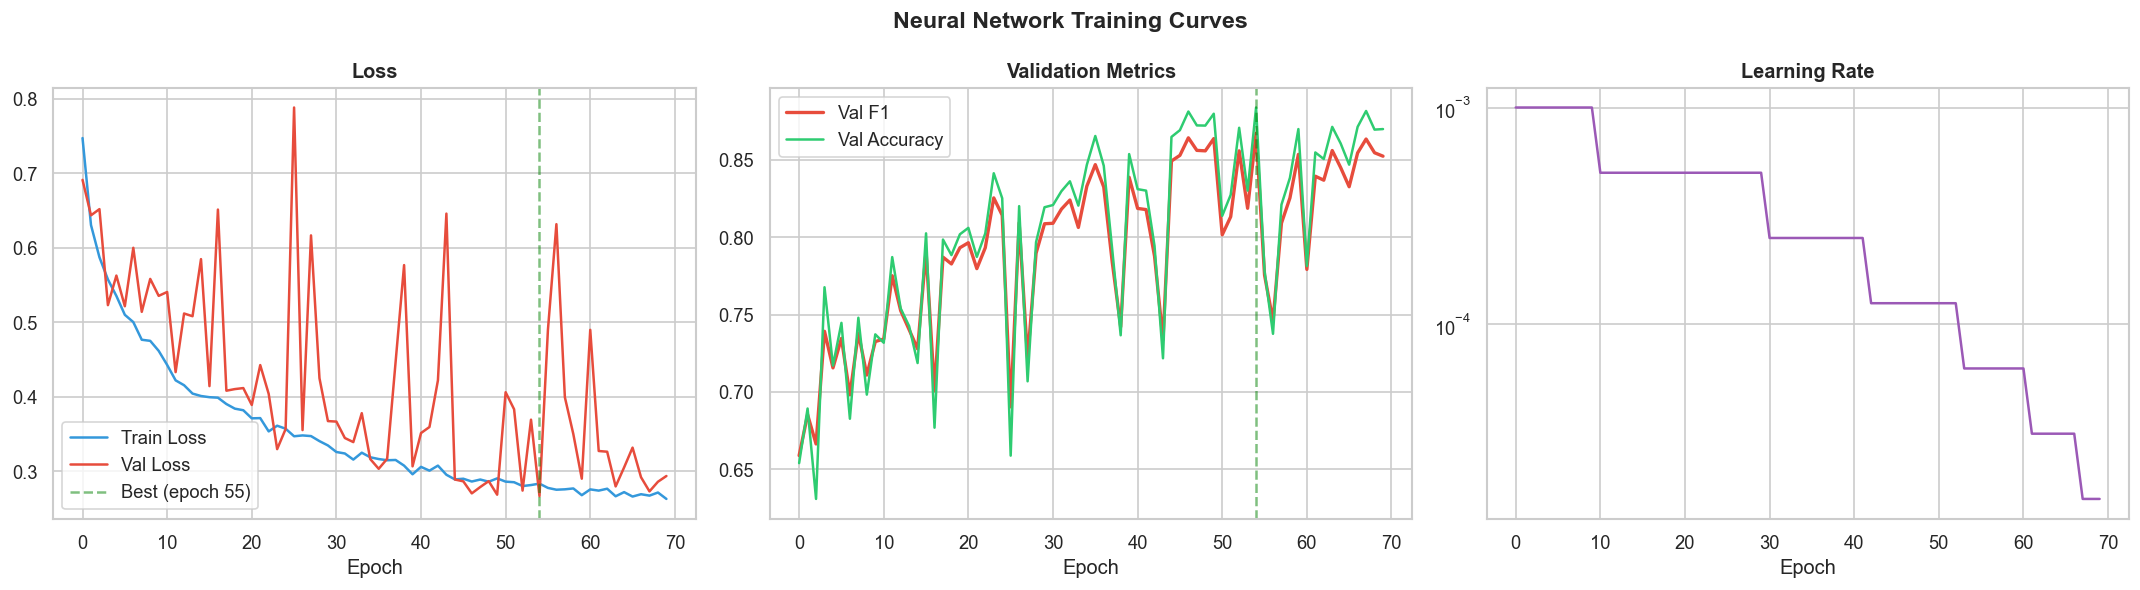

In [194]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='#3498db')    
axes[0].plot(history['val_loss'], label='Val Loss', color='#e74c3c')
axes[0].axvline(x=best_epoch - 1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[0].set_title("Loss", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].legend()

# F1 + Accuracy
axes[1].plot(history['val_f1'], label='Val F1', color='#e74c3c', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', color='#2ecc71')
axes[1].axvline(x=best_epoch - 1, color='green', linestyle='--', alpha=0.5)
axes[1].set_title("Validation Metrics", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Learning rate
axes[2].plot(history['lr'], color='#9b59b6')
axes[2].set_title("Learning Rate", fontweight='bold')
axes[2].set_xlabel("Epoch")
axes[2].set_yscale('log')

fig.suptitle("Neural Network Training Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [195]:
# Evaluate best NN on validation set
model_nn.eval()
all_logits = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        logits = model_nn(X_batch)
        all_logits.append(logits.cpu())

nn_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
nn_preds = (nn_probs >= 0.5).astype(int)

results['Neural Net'] = {
    'Accuracy':  accuracy_score(y_val, nn_preds),
    'F1':        f1_score(y_val, nn_preds),
    'Precision': precision_score(y_val, nn_preds),
    'Recall':    recall_score(y_val, nn_preds),
    'AUC-ROC':   roc_auc_score(y_val, nn_probs),
}

print(f"{'=' * 50}")
print(f"  Neural Network (best epoch: {best_epoch})")
print(f"{'=' * 50}")
for k, v in results['Neural Net'].items():
    print(f"  {k:<12}: {v:.4f}")
print(f"\n{classification_report(y_val, nn_preds, target_names=['Class 0', 'Class 1'])}")

  Neural Network (best epoch: 55)
  Accuracy    : 0.8840
  F1          : 0.8673
  Precision   : 0.8031
  Recall      : 0.9427
  AUC-ROC     : 0.9722

              precision    recall  f1-score   support

     Class 0       0.96      0.84      0.90      5060
     Class 1       0.80      0.94      0.87      3405

    accuracy                           0.88      8465
   macro avg       0.88      0.89      0.88      8465
weighted avg       0.89      0.88      0.89      8465



In [196]:
# Ensemble: Weighted average of best models
# Get probabilities from tuned LightGBM, tuned XGBoost, and Neural Net
lgb_probs  = lgb_tuned.predict_proba(X_val)[:, 1]
xgb_probs  = xgb_tuned.predict_proba(X_val)[:, 1]
nn_probs_v = nn_probs  # already computed above

# Try different weight combinations
weight_combos = [
    ("Equal (1:1:1)",         [1, 1, 1]),
    ("LGB heavy (3:2:1)",    [3, 2, 1]),
    ("XGB heavy (2:3:1)",    [2, 3, 1]),
    ("NN heavy (1:1:3)",     [1, 1, 3]),
    ("Tree only (1:1:0)",    [1, 1, 0]),
    ("LGB+NN (2:0:1)",       [2, 0, 1]),
]

print("=" * 70)
print("        ENSEMBLE WEIGHT SEARCH")
print("=" * 70)

best_ens_f1 = 0
best_weights = None

for label, w in weight_combos:
    w = np.array(w, dtype=float)
    w /= w.sum()  # normalize
    ens_probs = w[0] * lgb_probs + w[1] * xgb_probs + w[2] * nn_probs_v
    ens_preds = (ens_probs >= 0.5).astype(int)
    ens_f1  = f1_score(y_val, ens_preds)
    ens_acc = accuracy_score(y_val, ens_preds)
    ens_auc = roc_auc_score(y_val, ens_probs)
    print(f"  {label:<25} │ F1: {ens_f1:.4f} │ Acc: {ens_acc:.4f} │ AUC: {ens_auc:.4f}")

    if ens_f1 > best_ens_f1:
        best_ens_f1 = ens_f1
        best_weights = w.copy()
        best_label = label

print(f"\n🏆 Best ensemble: {best_label} → F1={best_ens_f1:.4f}")
print(f"   Weights: LGB={best_weights[0]:.2f}, XGB={best_weights[1]:.2f}, NN={best_weights[2]:.2f}")

        ENSEMBLE WEIGHT SEARCH
  Equal (1:1:1)             │ F1: 0.9859 │ Acc: 0.9887 │ AUC: 0.9976
  LGB heavy (3:2:1)         │ F1: 0.9866 │ Acc: 0.9892 │ AUC: 0.9983
  XGB heavy (2:3:1)         │ F1: 0.9870 │ Acc: 0.9896 │ AUC: 0.9984
  NN heavy (1:1:3)          │ F1: 0.9643 │ Acc: 0.9711 │ AUC: 0.9951
  Tree only (1:1:0)         │ F1: 0.9872 │ Acc: 0.9897 │ AUC: 0.9993
  LGB+NN (2:0:1)            │ F1: 0.9865 │ Acc: 0.9891 │ AUC: 0.9976

🏆 Best ensemble: Tree only (1:1:0) → F1=0.9872
   Weights: LGB=0.50, XGB=0.50, NN=0.00


  Ensemble (weights: Tree only (1:1:0))
  Accuracy    : 0.9897
  F1          : 0.9872
  Precision   : 0.9911
  Recall      : 0.9833
  AUC-ROC     : 0.9993

              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      5060
     Class 1       0.99      0.98      0.99      3405

    accuracy                           0.99      8465
   macro avg       0.99      0.99      0.99      8465
weighted avg       0.99      0.99      0.99      8465



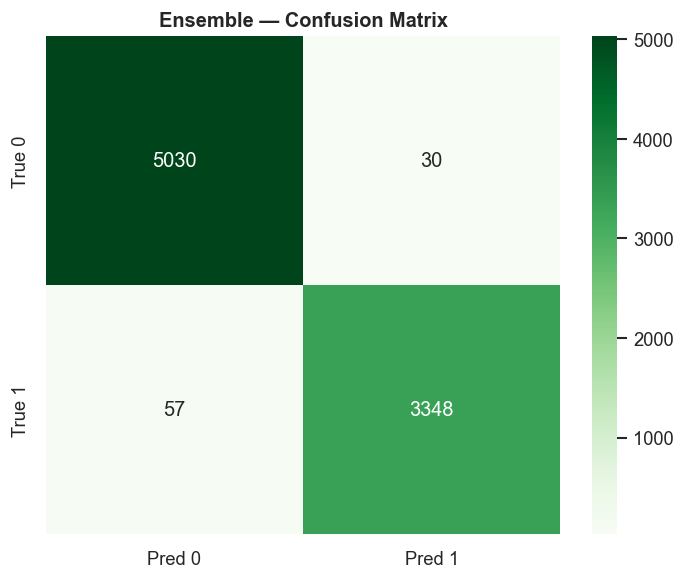

In [197]:
# Evaluate best ensemble on validation
ens_probs_final = best_weights[0] * lgb_probs + best_weights[1] * xgb_probs + best_weights[2] * nn_probs_v
ens_preds_final = (ens_probs_final >= 0.5).astype(int)

results['Ensemble'] = {
    'Accuracy':  accuracy_score(y_val, ens_preds_final),
    'F1':        f1_score(y_val, ens_preds_final),
    'Precision': precision_score(y_val, ens_preds_final),
    'Recall':    recall_score(y_val, ens_preds_final),
    'AUC-ROC':   roc_auc_score(y_val, ens_probs_final),
}

print(f"{'=' * 50}")
print(f"  Ensemble (weights: {best_label})")
print(f"{'=' * 50}")
for k, v in results['Ensemble'].items():
    print(f"  {k:<12}: {v:.4f}")
print(f"\n{classification_report(y_val, ens_preds_final, target_names=['Class 0', 'Class 1'])}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, ens_preds_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax.set_title("Ensemble — Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

In [198]:
# FULL final comparison
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)

print("=" * 75)
print("           FINAL MODEL COMPARISON (sorted by F1)")
print("=" * 75)
print(results_df.to_string())

best_final = results_df.index[0]
print(f"\n🏆 WINNER: {best_final}")
print(f"   F1={results_df.loc[best_final, 'F1']:.4f}  "
      f"AUC={results_df.loc[best_final, 'AUC-ROC']:.4f}  "
      f"Acc={results_df.loc[best_final, 'Accuracy']:.4f}")

           FINAL MODEL COMPARISON (sorted by F1)
                     Accuracy        F1  Precision    Recall   AUC-ROC  Time (s)
Ensemble             0.989722  0.987174   0.991119  0.983260  0.999342       NaN
LightGBM             0.989486  0.986887   0.990242  0.983554  0.999199       NaN
XGBoost (tuned)      0.989486  0.986867   0.991696  0.982085  0.999340       NaN
LightGBM (tuned)     0.989368  0.986722   0.991402  0.982085  0.999195       NaN
XGBoost              0.988895  0.986164   0.988492  0.983847  0.998902       NaN
Random Forest        0.980035  0.974810   0.989709  0.960352  0.998615    169.26
Neural Net           0.883993  0.867333   0.803102  0.942731  0.972215       NaN
Logistic Regression  0.806615  0.743054   0.798045  0.695154  0.867571     25.31

🏆 WINNER: Ensemble
   F1=0.9872  AUC=0.9993  Acc=0.9897


In [199]:
# Generate test predictions with best approach
# ---- LightGBM tuned on test ----
lgb_test_probs = lgb_tuned.predict_proba(X_test_scaled)[:, 1]

# ---- XGBoost tuned on test ----
xgb_test_probs = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

# ---- Neural Net on test ----
model_nn.eval()
nn_test_logits = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model_nn(X_batch)
        nn_test_logits.append(logits.cpu())
nn_test_probs = torch.sigmoid(torch.cat(nn_test_logits)).numpy()

# ---- Ensemble ----
test_probs = best_weights[0] * lgb_test_probs + best_weights[1] * xgb_test_probs + best_weights[2] * nn_test_probs
test_preds = (test_probs >= 0.5).astype(int)

print(f"Test predictions generated: {len(test_preds)}")
print(f"Class distribution in predictions:")
print(f"  Class 0: {(test_preds == 0).sum()}")
print(f"  Class 1: {(test_preds == 1).sum()}")
print(f"  Ratio  : 1:{(test_preds == 1).sum() / max((test_preds == 0).sum(), 1):.2f}")

Test predictions generated: 10944
Class distribution in predictions:
  Class 0: 6673
  Class 1: 4271
  Ratio  : 1:0.64


In [200]:
# Create submission CSV
submission = pd.DataFrame({
    'ID': test_ids,
    'Class': test_preds
})

# Validation checks
assert len(submission) == len(test_df), f"Row count mismatch! Expected {len(test_df)}, got {len(submission)}"
assert set(submission['Class'].unique()).issubset({0, 1}), "Invalid class values!"
assert submission['ID'].is_unique, "Duplicate IDs found!"

submission.to_csv("FINAL.csv", index=False)

print("=" * 50)
print("  ✅ SUBMISSION FILE SAVED: FINAL.csv")
print("=" * 50)
print(f"  Rows   : {len(submission)}")
print(f"  Columns: {list(submission.columns)}")
print(f"  Class 0: {(submission['Class'] == 0).sum()}")
print(f"  Class 1: {(submission['Class'] == 1).sum()}")
print(f"\nFirst 10 rows:")
print(submission.head(10).to_string(index=False))

  ✅ SUBMISSION FILE SAVED: FINAL.csv
  Rows   : 10944
  Columns: ['ID', 'Class']
  Class 0: 6673
  Class 1: 4271

First 10 rows:
 ID  Class
  1      1
  2      0
  3      1
  4      0
  5      0
  6      1
  7      0
  8      1
  9      1
 10      0


In [201]:
# Cell 61 - Final summary
print("=" * 70)
print("              PROJECT COMPLETE — FINAL SUMMARY")
print("=" * 70)
print(f"""
📊 Dataset
   Train samples : {len(train_df)}
   Test samples  : {len(test_df)}
   Features (raw): 47

🔧 Preprocessing
   Dropped (corr > 0.95): {len(drop_cols)}
   Added stat features  : {len(new_cols)}
   Added interactions   : {len(interaction_cols)}
   Dropped (low MI)     : {len(low_mi)}
   Final features       : {X_scaled.shape[1]}
   Scaler               : RobustScaler

🤖 Models Trained
   1. Logistic Regression (baseline)
   2. Random Forest
   3. XGBoost + Optuna tuning
   4. LightGBM + Optuna tuning
   5. Neural Network (PyTorch)
   6. Weighted Ensemble

🏆 Best Model: {best_final}
   F1      : {results_df.loc[best_final, 'F1']:.4f}
   AUC-ROC : {results_df.loc[best_final, 'AUC-ROC']:.4f}
   Accuracy: {results_df.loc[best_final, 'Accuracy']:.4f}

📁 Output: FINAL.csv ({len(submission)} rows)
""")
print("=" * 70)

              PROJECT COMPLETE — FINAL SUMMARY

📊 Dataset
   Train samples : 43776
   Test samples  : 10944
   Features (raw): 47

🔧 Preprocessing
   Dropped (corr > 0.95): 6
   Added stat features  : 11
   Added interactions   : 90
   Dropped (low MI)     : 0
   Final features       : 142
   Scaler               : RobustScaler

🤖 Models Trained
   1. Logistic Regression (baseline)
   2. Random Forest
   3. XGBoost + Optuna tuning
   4. LightGBM + Optuna tuning
   5. Neural Network (PyTorch)
   6. Weighted Ensemble

🏆 Best Model: Ensemble
   F1      : 0.9872
   AUC-ROC : 0.9993
   Accuracy: 0.9897

📁 Output: FINAL.csv (10944 rows)

